In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import plotly.express as px
from pathlib import Path
from scipy.stats import probplot, f_oneway,chi2_contingency


In [2]:
# pathlib is a module in Python that provides an object-oriented interface 
# for working with file system paths.
current = Path.cwd()
parent = current.parent
# load the data 

df = pd.read_csv(parent /"data"/"cleaned_data.csv")
# Display the first few rows of the DataFrame
display(df.head())

,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility,luxury_facility_scores
0,sattva songbird,Old Madras Road,east,1,Under Construction,510.0,NaN,NaN,1.10,"[('rcb int school', '7.3 km'), ('garden city u...","[""Children's Play Area"", 'Park', 'Gymnasium', ...",50
1,brigade sanctuary,Chikkavaderapura,east,1,Under Construction,NaN,NaN,656.0,0.88,"[('oakridge international school bangalore', '...","[""Children's Play Area"", 'Creche/Day Care', 'J...",70
2,sobha neopolis,Panathur,east,1,New Property,435.0,NaN,NaN,0.89,"[('sarah montessori school', '1.4 kms'), ('h '...","['Yoga/Meditation Area', 'Jogging Track', 'Ska...",72
3,nambiar millennia,Sarjapur Road,east,1,Under Construction,NaN,668.0,NaN,0.53,"[('mahatma vidhyalaya', '400 m'), ('eterssrt m...","['Yoga/Meditation Area', ""Children's Play Area...",69
4,provident capella,Samethanahalli,east,1,New Property,NaN,NaN,480.0,0.55,"[('soukya road', '1.4 km'), ('mvj college of e...","[""Children's Play Area"", 'Creche/Day Care', 'J...",70


In [3]:
df.isnull().sum()

apartment_name              12
appartment_loc               3
zone                         0
bhk_type                     0
construction_status          0
carpet_area               2774
bulit_area                4721
super_bulit_area          2505
price_value                  2
nearbylocation             296
facility                   512
luxury_facility_scores       0
dtype: int64

In [4]:
# number of rows  in the data that have missing values

missing_rows = (
    df
    .isnull()
    .any(axis=1)
    .sum()
    )

print(f"Number of rows with missing values: {missing_rows}")
# Display the percentage of missing values 
print(f"Percentage of missing values: {missing_rows / len(df) * 100:.2f}%")
# shape of the data
print("number of rows in the data:",df.shape[0])

Number of rows with missing values: 5925
Percentage of missing values: 90.29%
number of rows in the data: 6562


In [5]:
# check if there are any duplicate rows in the DataFrame
df.duplicated().sum()
# df.drop_duplicates(inplace=True)


np.int64(0)

In [6]:
# data types
df.dtypes

apartment_name             object
appartment_loc             object
zone                       object
bhk_type                    int64
construction_status        object
carpet_area               float64
bulit_area                float64
super_bulit_area          float64
price_value               float64
nearbylocation             object
facility                   object
luxury_facility_scores      int64
dtype: object

In [7]:
# numeric columns
num_cols = df.columns[[5,6,7,8,11]].to_list()

# categorical columns
cat_cols  = [col for col in df.columns if col not in num_cols]
print(f"there are {len(num_cols)} numeric columns and {len(cat_cols)} categorical columns in the dataset")
print("*"*50)
# Display the numeric columns
print("Numeric columns:", num_cols)
# Display the categorical columns
print("*"*50)
print("Categorical columns:", cat_cols)
print("*"*50)


there are 5 numeric columns and 7 categorical columns in the dataset
**************************************************
Numeric columns: ['carpet_area', 'bulit_area', 'super_bulit_area', 'price_value', 'luxury_facility_scores']
**************************************************
Categorical columns: ['apartment_name', 'appartment_loc', 'zone', 'bhk_type', 'construction_status', 'nearbylocation', 'facility']
**************************************************


In [8]:
# statistical summary of the numeric columns
df[num_cols].describe()

,carpet_area,bulit_area,super_bulit_area,price_value,luxury_facility_scores
count,3788.000000,1841.000000,4057.000000,6560.000000,6562.000000
mean,1360.155058,1693.301119,1747.041415,1.912163,81.788174
std,897.065369,1076.756024,1063.592821,1.932520,52.261447
min,10.000000,27.000000,31.840000,0.090000,0.000000
25%,851.500000,1100.000000,1128.000000,0.760000,48.000000
50%,1131.000000,1359.000000,1430.000000,1.200000,73.000000
75%,1520.000000,1900.000000,1975.000000,2.320000,114.000000
max,7825.000000,8000.000000,7900.000000,21.420000,223.000000


In [9]:
# statistical summary of the categorical columns
df.describe(include="object").T

,count,unique,top,freq
apartment_name,6550,2476,kvg superior,140
appartment_loc,6559,844,Whitefield,467
zone,6562,4,east,2269
construction_status,6562,6,New Property,2082
nearbylocation,6266,2540,"['ITPL Metro Station', 'Nexus Shantiniketan', ...",76
facility,6050,3747,"['Feng Shui / Vaastu Compliant', 'Security / F...",182


In [10]:
import missingno as msno

<Axes: >

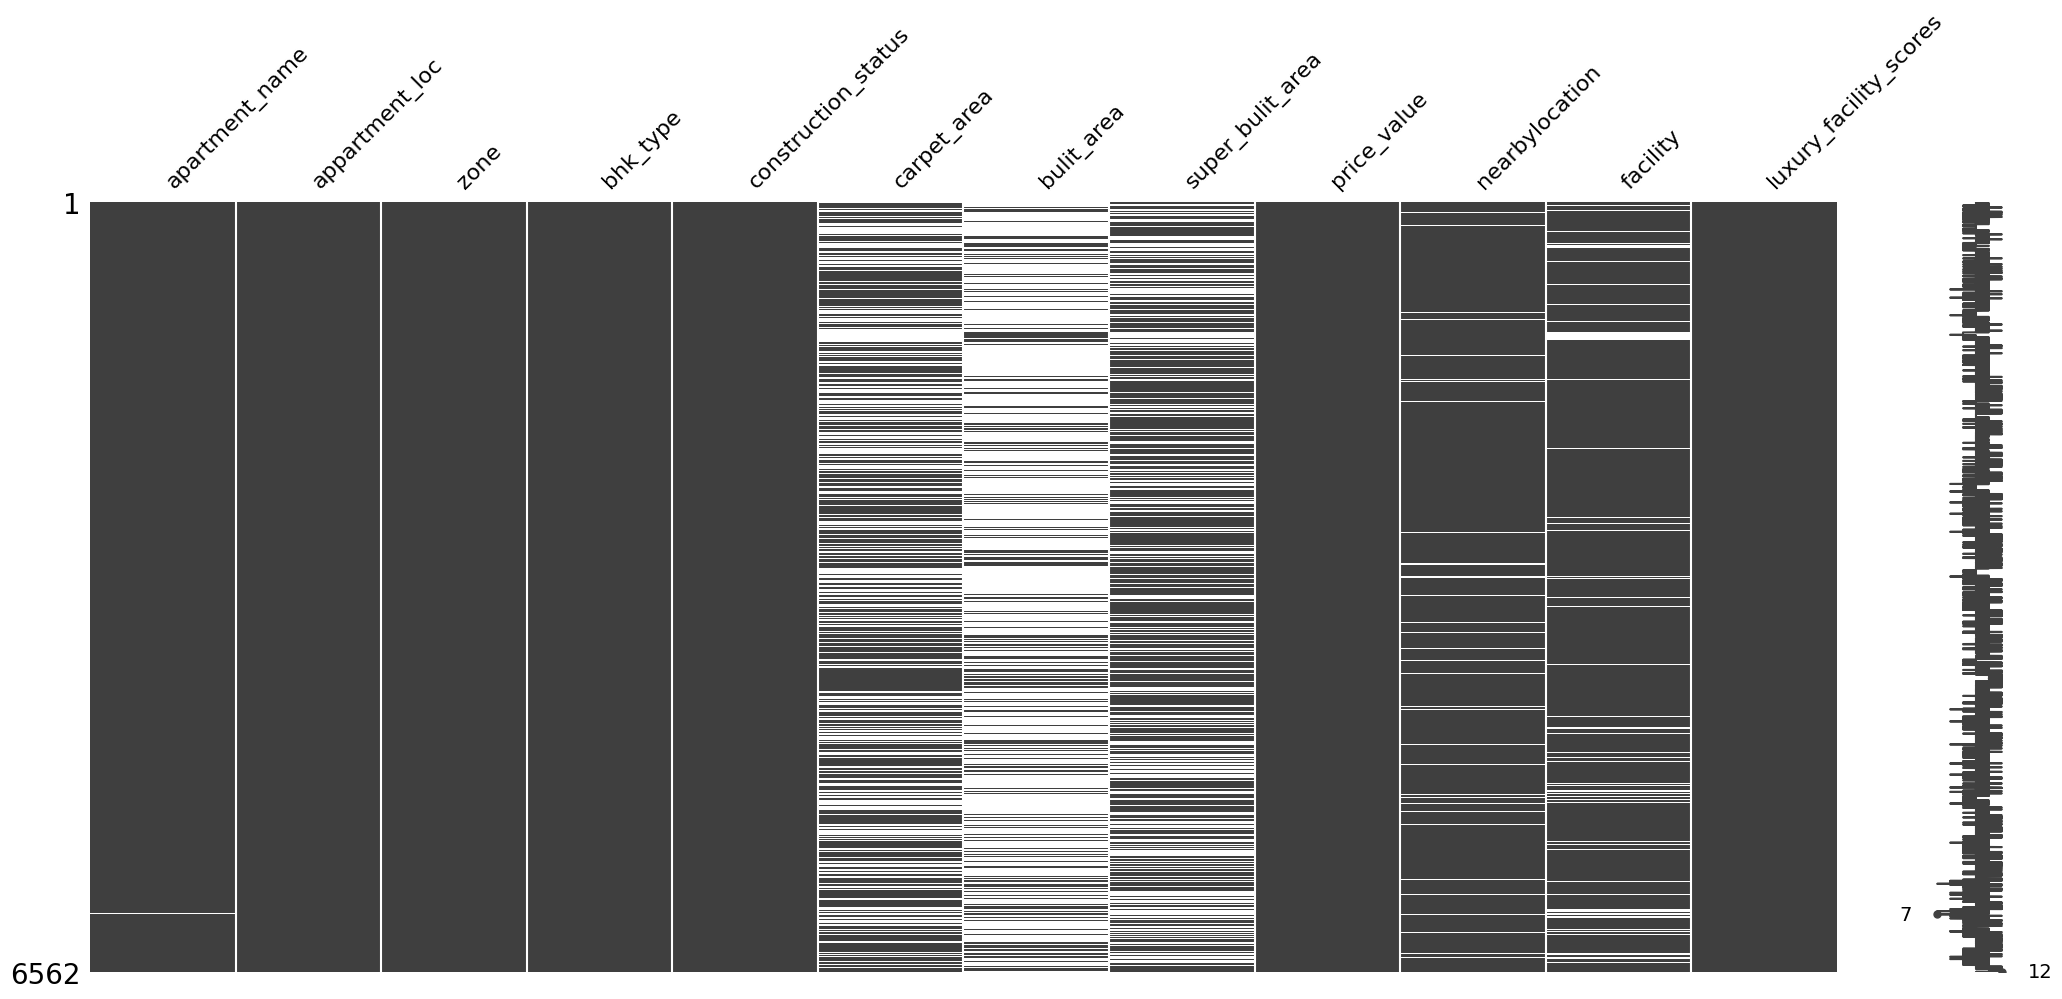

In [11]:
msno.matrix(df)

<Axes: >

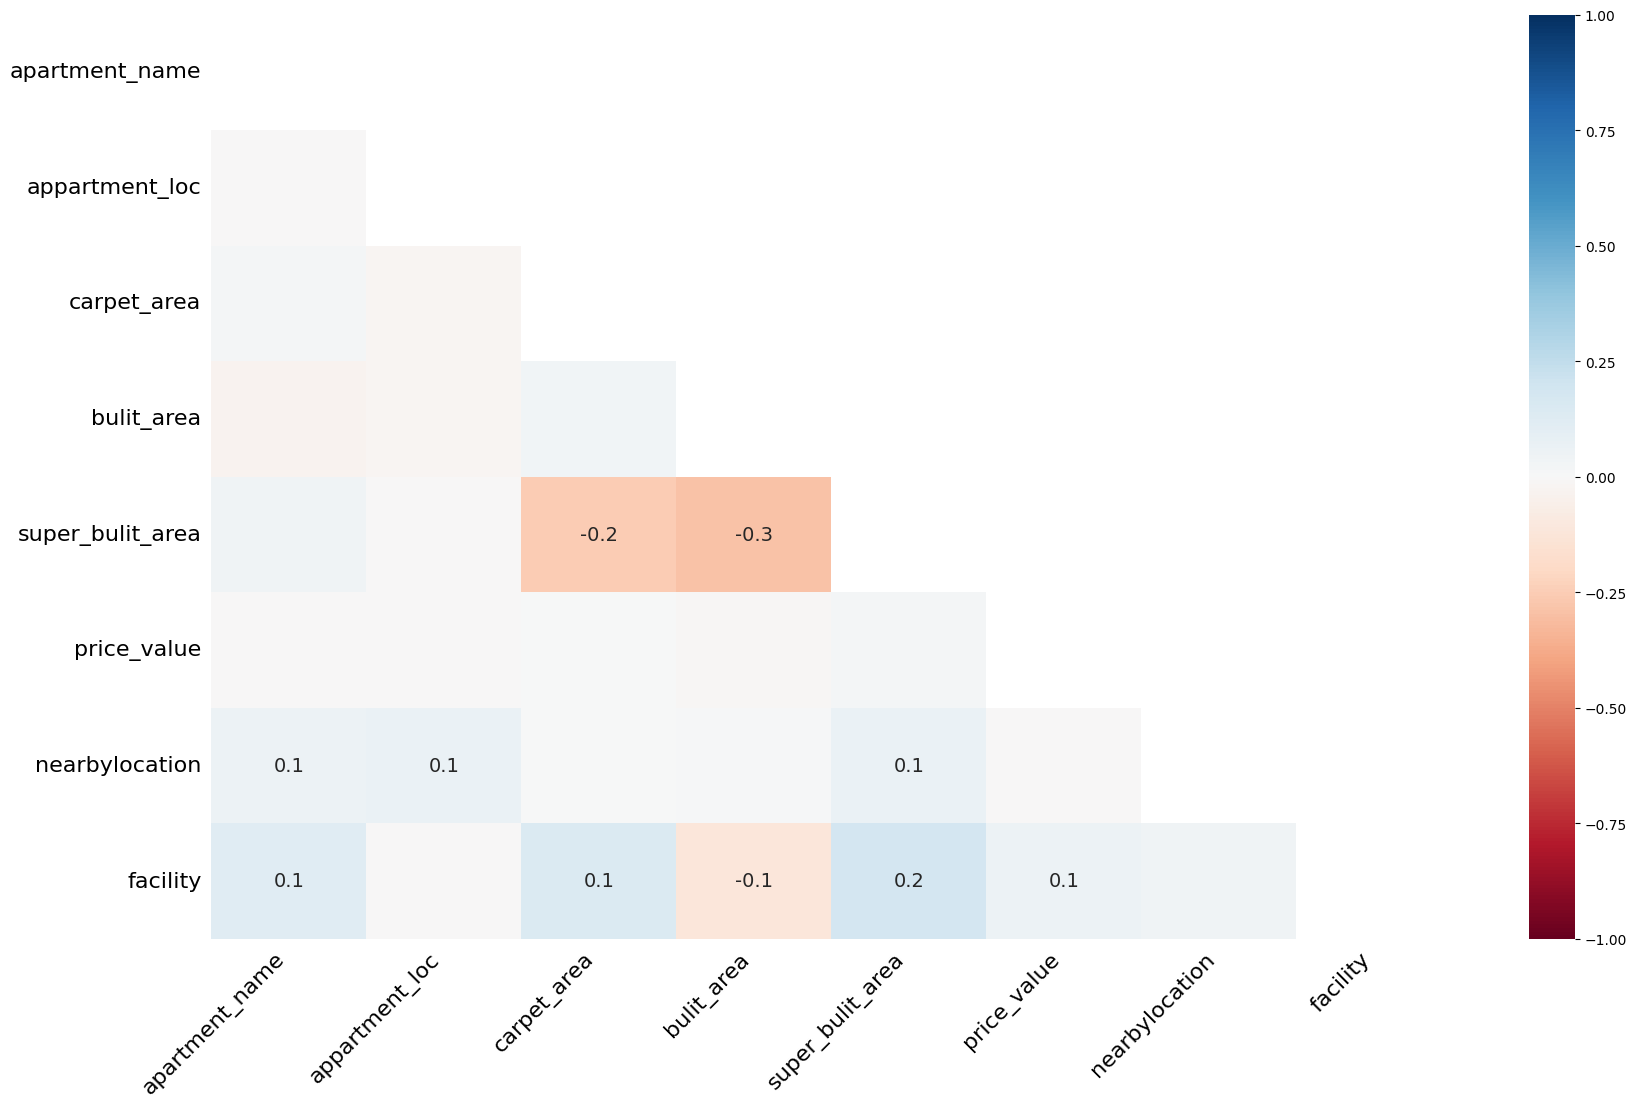

In [12]:
msno.heatmap(df)

### Dendrogram

<Axes: >

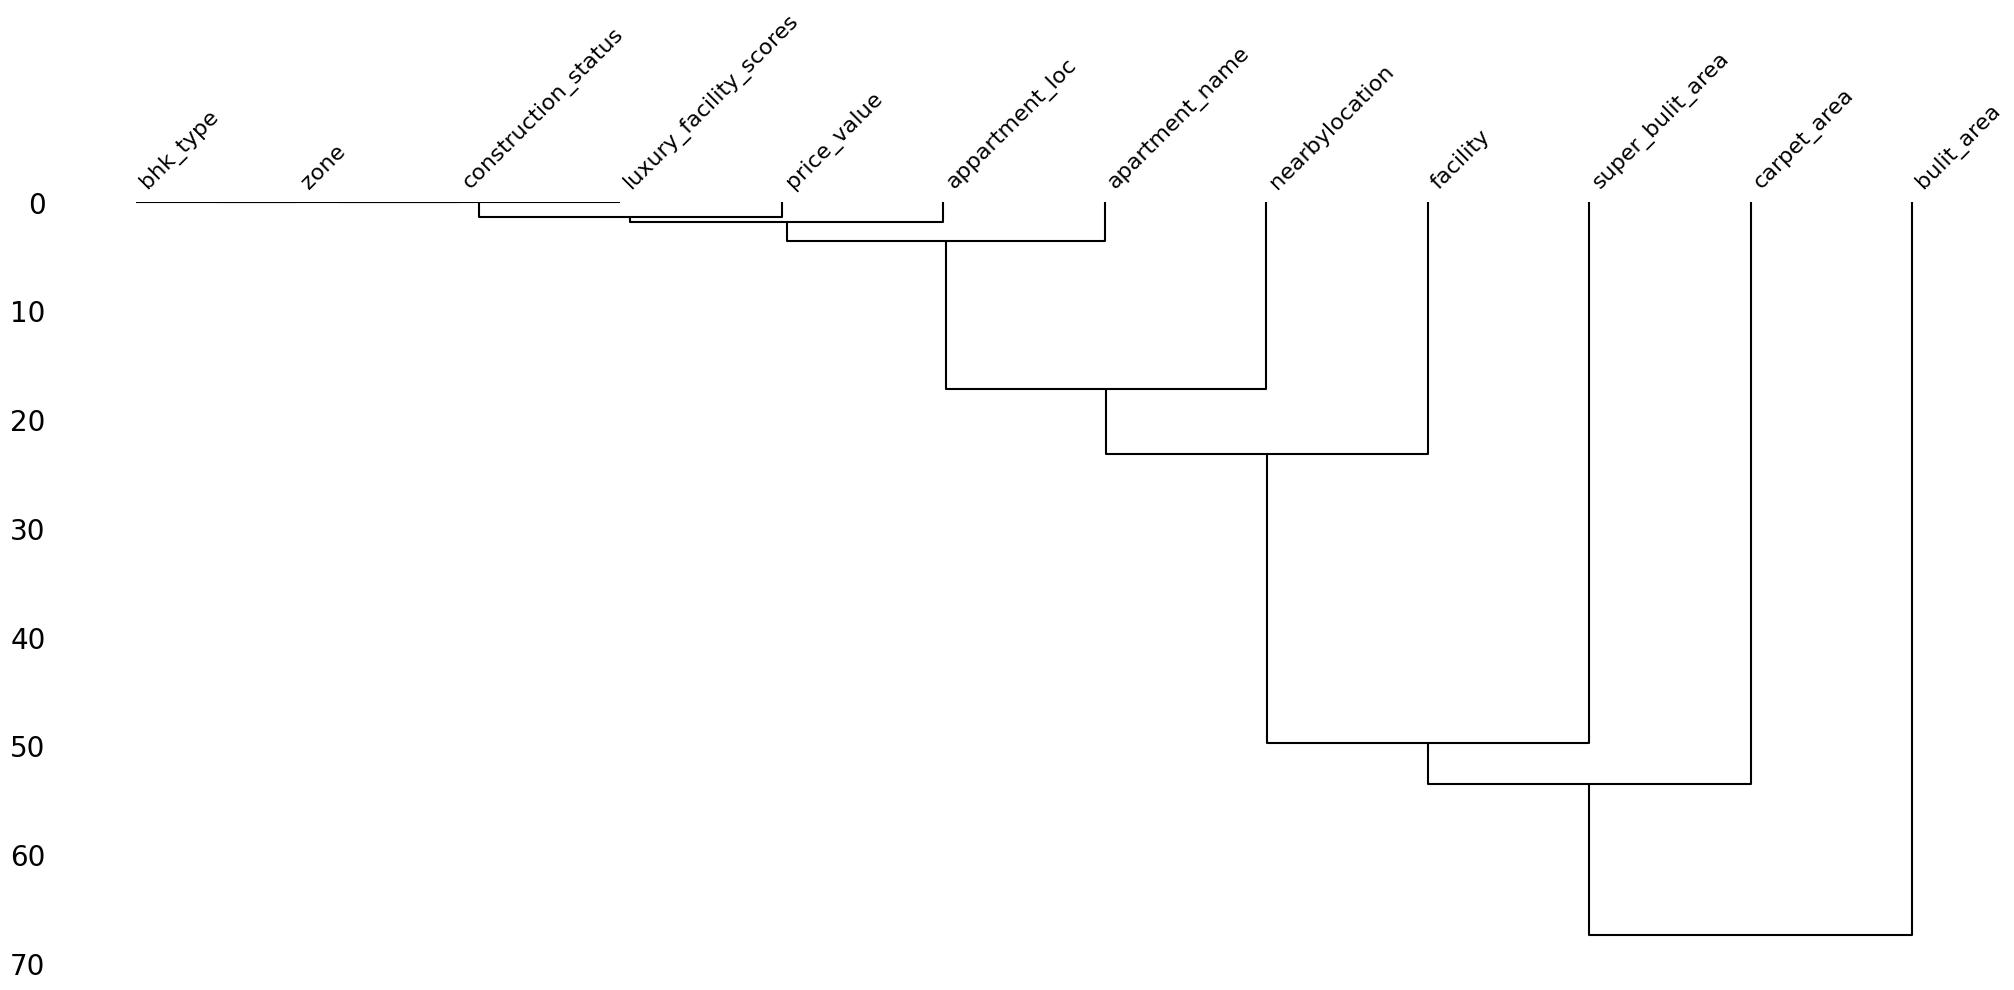

In [13]:
msno.dendrogram(df)

In [14]:
def numerical_analysis(df, column_name,cat_col=None,bins="auto"):
    fig = plt.figure(figsize=(15, 8))
    # create the grid
    gs = GridSpec(nrows= 2, ncols=2, figure=fig)
    # create the first subplot
    ax1 = fig.add_subplot(gs[0, 0]) 
    # create the second subplot
    ax2 = fig.add_subplot(gs[0, 1])
    # create the third subplot
    ax3 = fig.add_subplot(gs[1, :])
    # plot the kde plot
    sns.kdeplot(df[column_name], ax=ax1,hue=cat_col)
    # plot the box plot
    sns.boxplot(x=df[column_name], ax=ax2, hue=cat_col)
    # plot the histogram
    sns.histplot(df[column_name], ax=ax3, bins=bins, kde=True)
    plt.tight_layout()
    plt.show()

# Column Wise Analysis

In [145]:
## Numerical Analysis Univariate Analysis

In [15]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores'],
      dtype='object')

### price value analysis (Target)

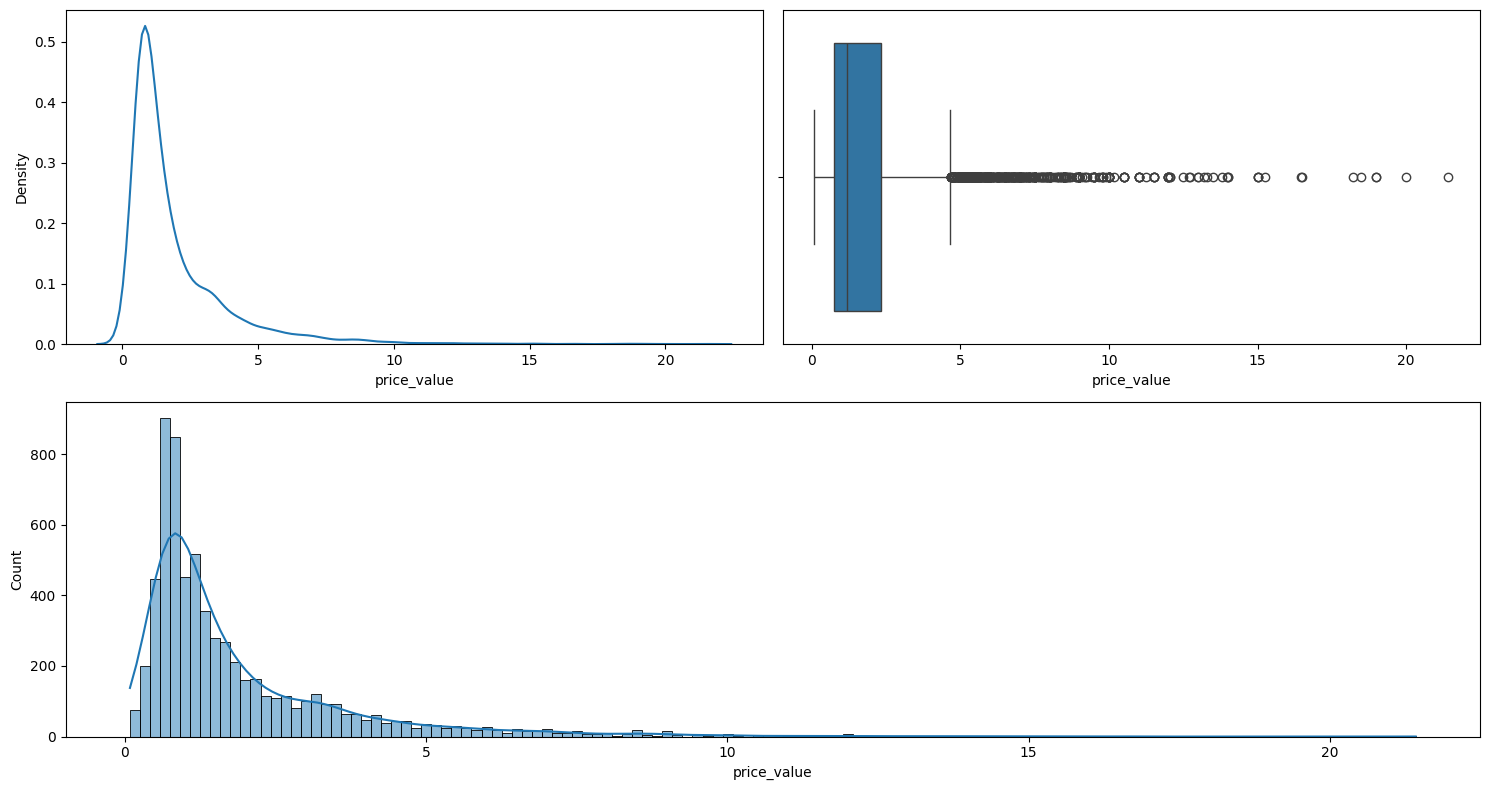

In [16]:
numerical_analysis(df, "price_value")


---

### 📊 **Observations on `price_value` Distribution**

#### 1. **Distribution Shape**

* The **KDE plot** (top-left) and **histogram** (bottom) both show a **right-skewed distribution** of `price_value`.
* Most values are concentrated near **0–2**, with a **long tail** extending beyond **20**, indicating a significant skew.

#### 2. **Presence of Outliers**

* The **box plot** (top-right) reveals a **large number of outliers** above the upper whisker.
* These outliers can **distort model predictions** if not handled appropriately.

#### 3. **Modeling Implications**

* The skewness and outliers suggest that the `price_value` variable does **not follow a normal distribution**, which can negatively affect many machine learning models.
* Applying a **log transformation** (e.g., `log(price_value + 1)`) would:

  * Compress the long tail,
  * **Reduce the influence of outliers**,
  * Help approximate **normality**,
  * Improve **model stability and accuracy**, especially in regression tasks.

----

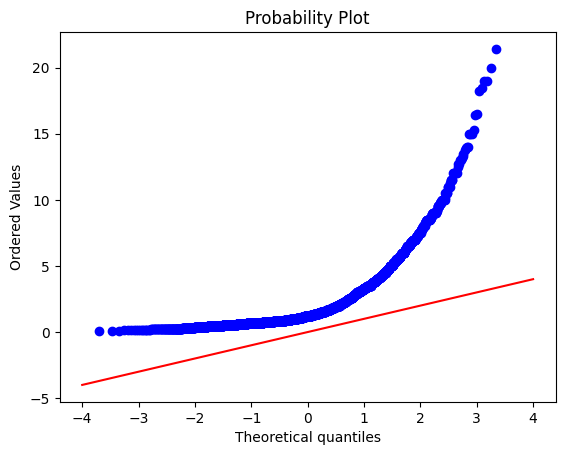

In [17]:
# plot QQ plot for the target 
probplot(df["price_value"], dist="norm", plot=plt)
# Manually add reference line
x = np.linspace(-4, 4, 100)
plt.plot(x, x, 'r-', linewidth=1.5)
plt.show()

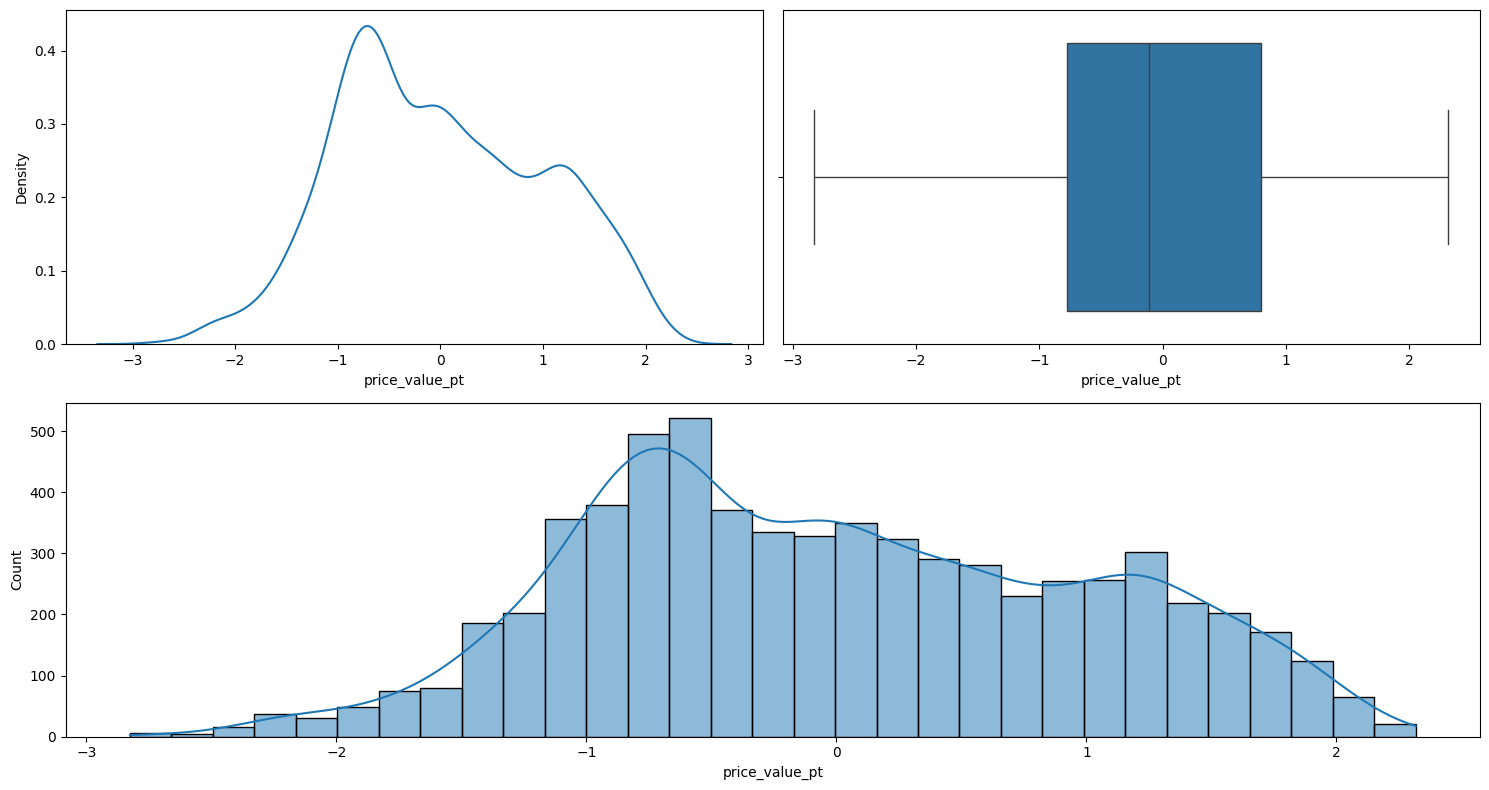

In [18]:
# fix traget column using transformation

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
df["price_value_pt"] = pt.fit_transform(df[["price_value"]])

numerical_analysis(df, "price_value_pt")

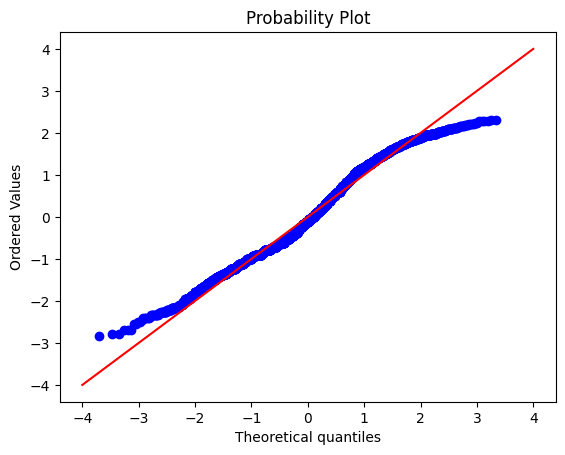

In [19]:
 # Create Q-Q plot
probplot(df["price_value_pt"], dist="norm", plot=plt)

# Manually add reference line
x = np.linspace(-4, 4, 100)
plt.plot(x, x, 'r-', linewidth=1.5)  # red line with specified thickness

plt.title("Probability Plot")
plt.show()

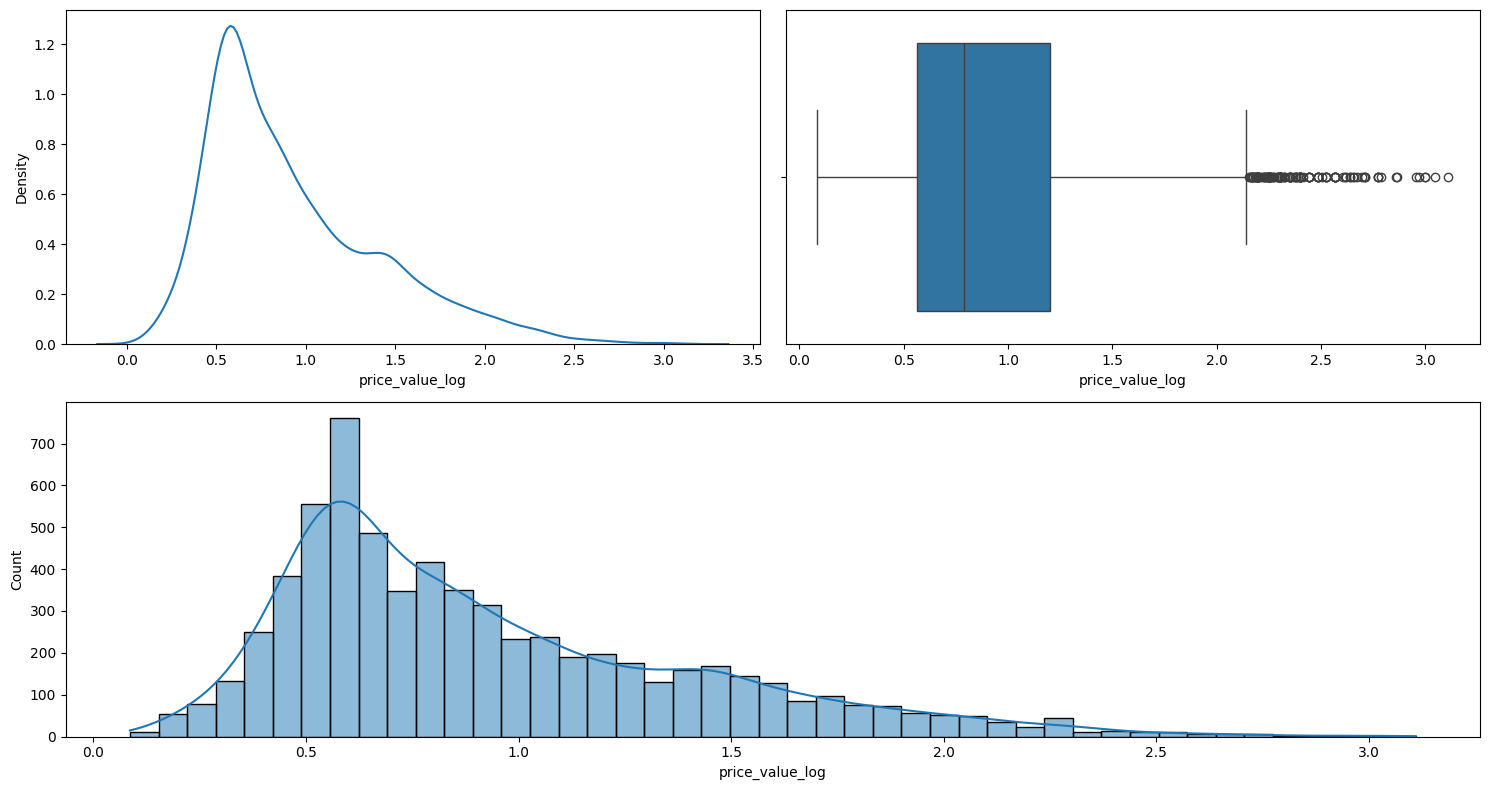

In [20]:
# Apply log transformation to 'price_value'
df['price_value_log'] = np.log1p(df['price_value'])

# Now you can perform numerical analysis on the log-transformed column
numerical_analysis(df, "price_value_log")

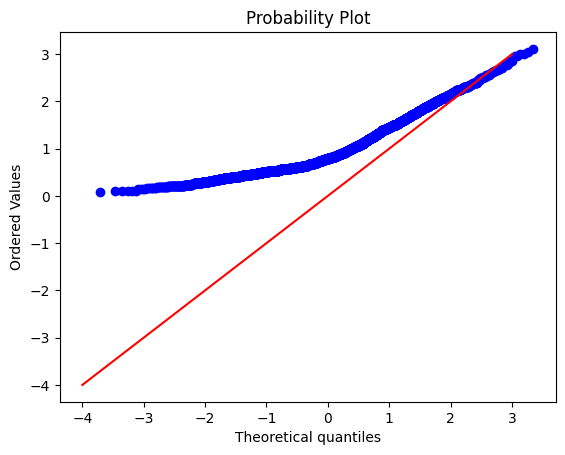

In [21]:
# plot QQ plot for the target 
probplot(df["price_value_log"], dist="norm", plot=plt)
# Manually add reference line
x = np.linspace(-4, 3, 100)
plt.plot(x, x, 'r-', linewidth=1.5)
plt.show()

In [153]:
df .columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

### Carpet Area 

In [22]:
df['carpet_area']

0        510.0
1          NaN
2        435.0
3          NaN
4          NaN
         ...  
6557    1520.0
6558    2000.0
6559    1162.0
6560    1429.0
6561    2077.0
Name: carpet_area, Length: 6562, dtype: float64

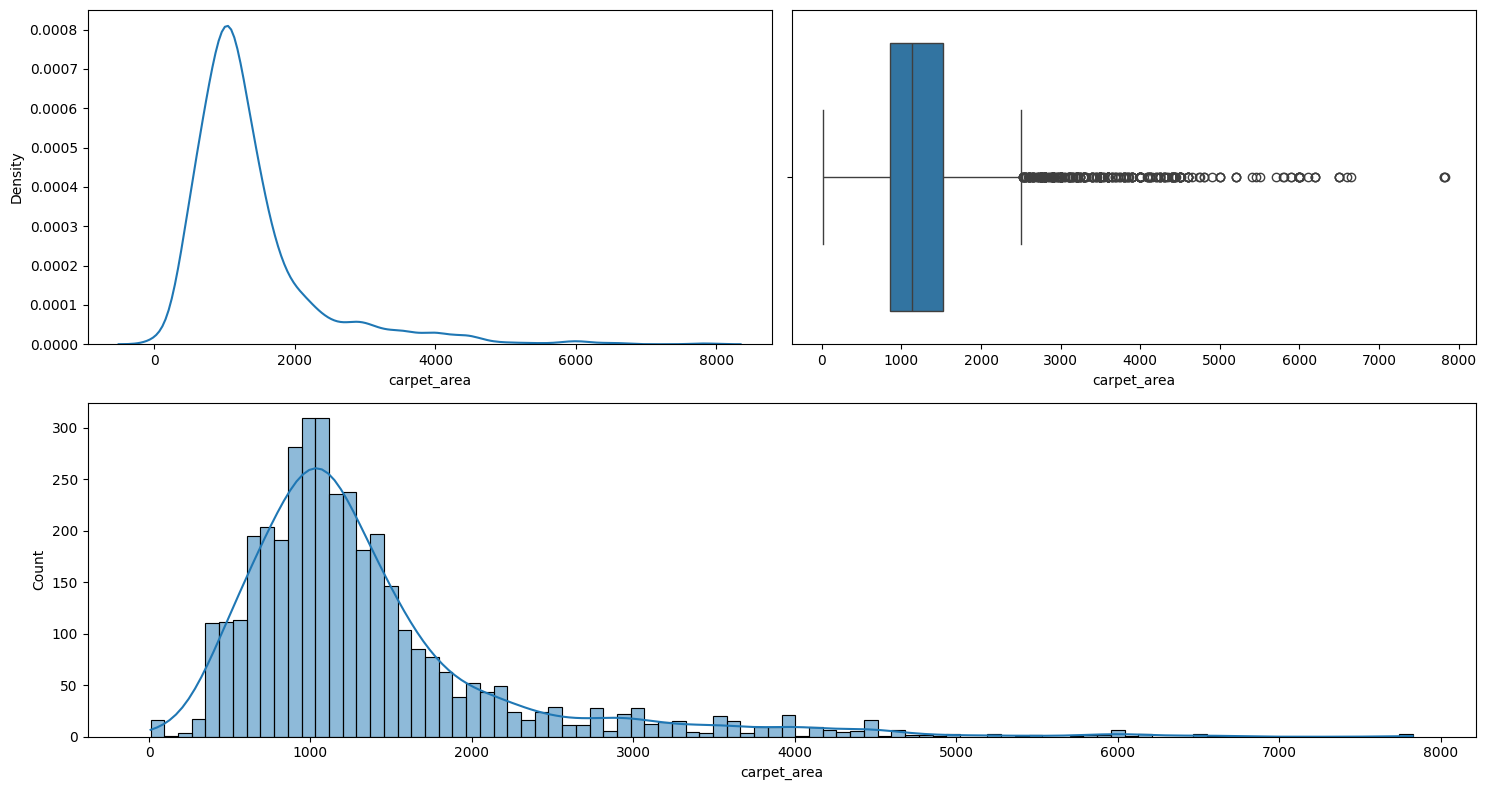

In [23]:
numerical_analysis(df, "carpet_area")

In [24]:
df[['apartment_name', 'appartment_loc','carpet_area','price_value']][df['carpet_area']>2800].sort_values(by='price_value',ascending=False)

,apartment_name,appartment_loc,carpet_area,price_value
4110,shri sai associates,RMV 2nd block 2nd Stage,6500.0,16.50
3189,embassy one,Hebbal,5451.0,15.26
6497,phoenix kessaku,Rajajinagar,4500.0,15.00
1778,total wdmills of your md,Whitefield,6000.0,14.00
6516,phoenix kessaku,Rajajinagar,4000.0,14.00
...,...,...,...,...
3151,birla trimaya,Devanahalli,3088.0,2.29
6129,vanani apartments,Vijayashree Layout,2900.0,2.25
2050,fern saroj apartments,LB Shastri Nagar,4300.0,2.00
6483,rayal oak,magadi road,4200.0,1.80


Its evident price value is higher for large carpet area
and for few data points price value is higher for small carpet area may be due to location 


### bulit area

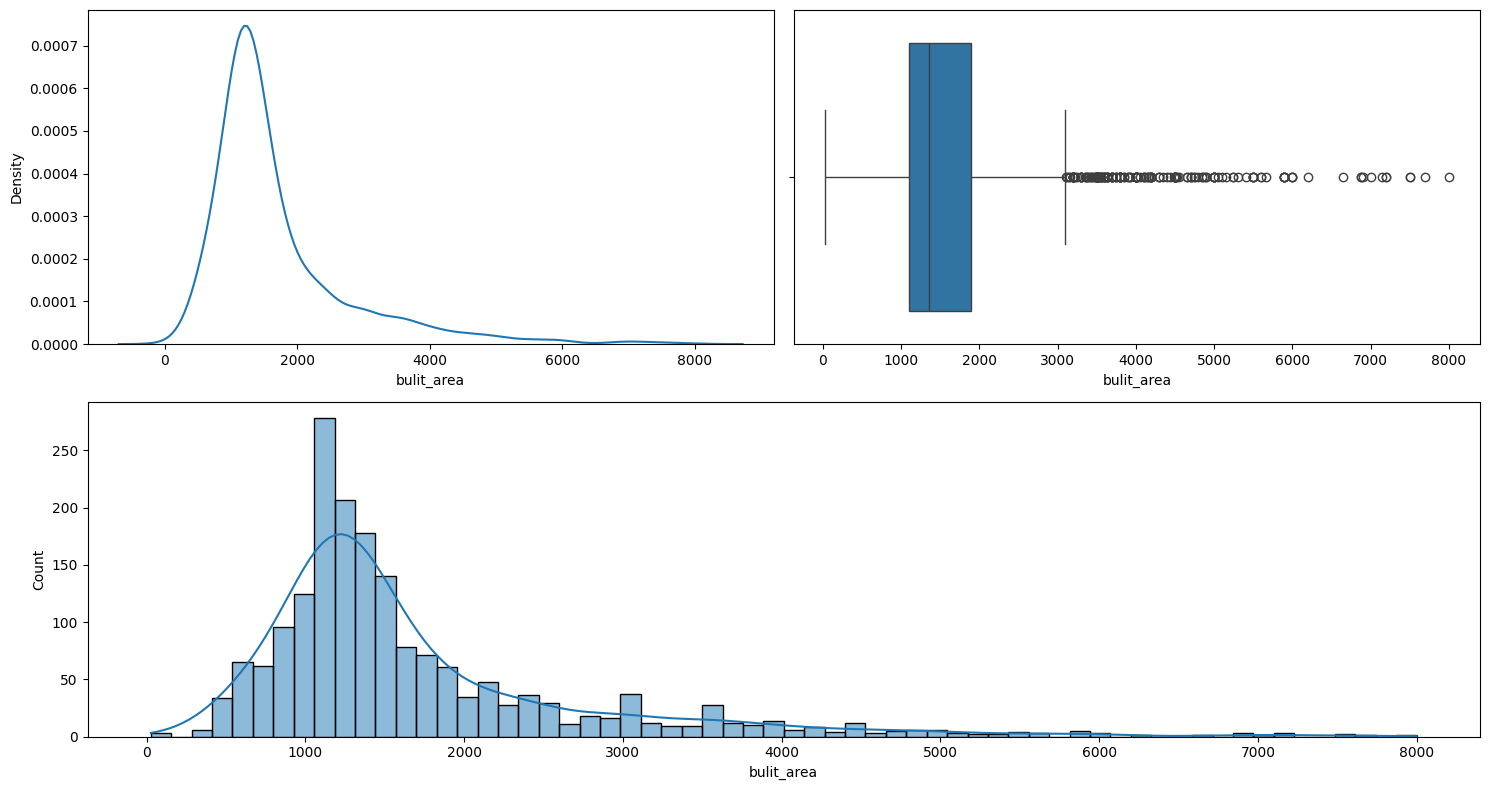

In [25]:
numerical_analysis(df, "bulit_area")

### Super Bulit Area

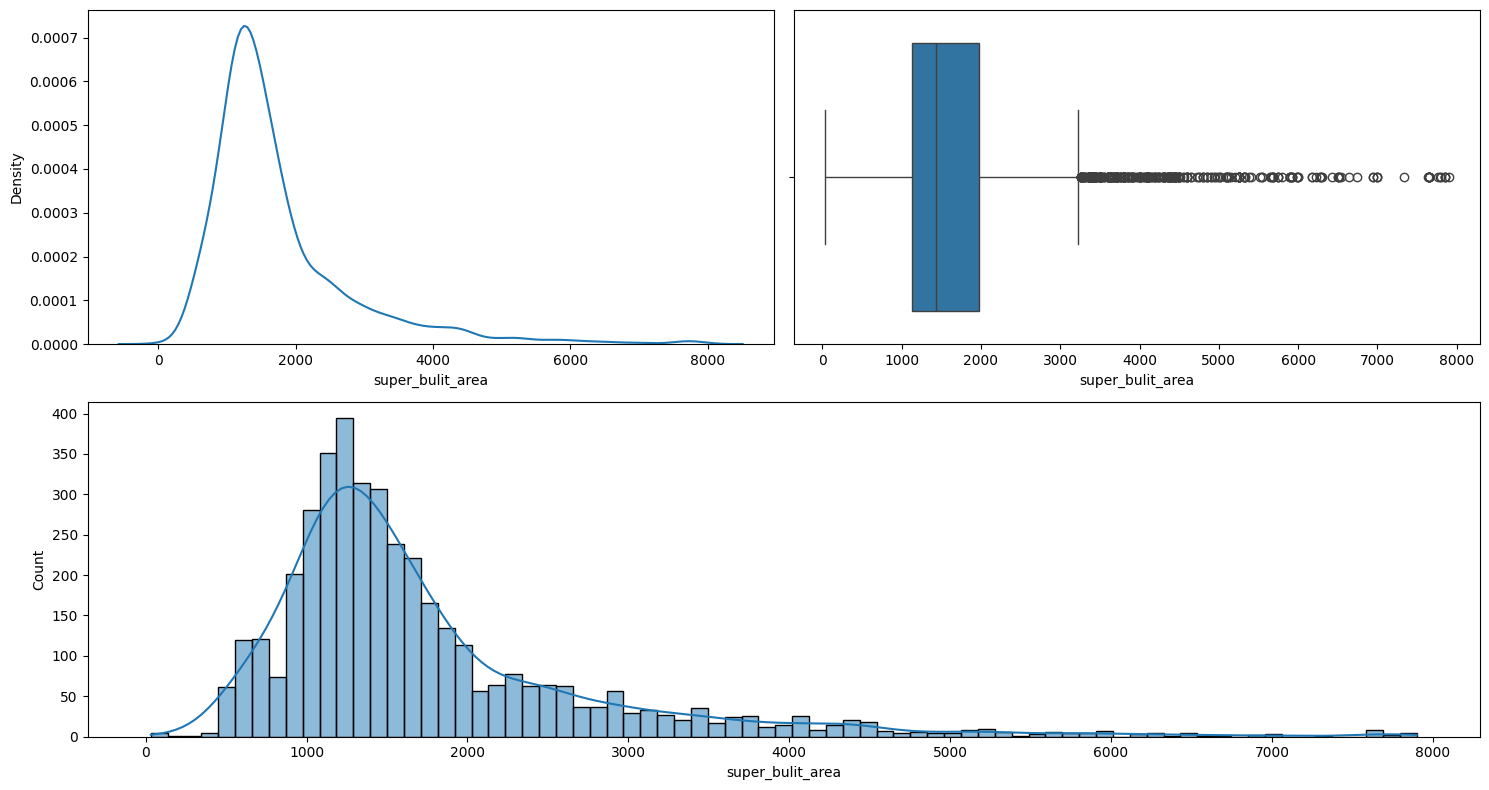

In [157]:
numerical_analysis(df, "super_bulit_area")

### luxury facility scores 

In [158]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

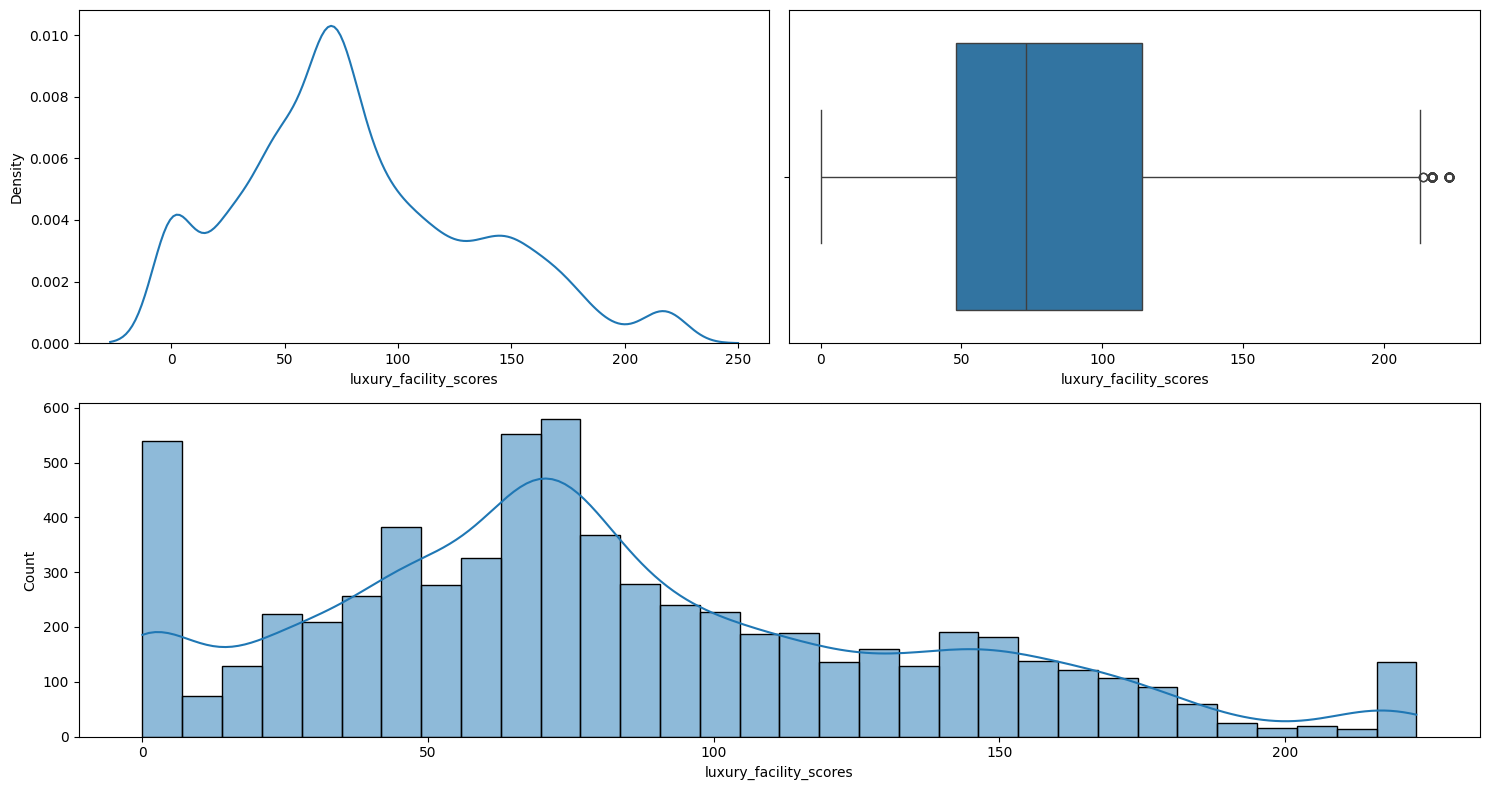

In [159]:
numerical_analysis(df, "luxury_facility_scores")

## Categorical Analysis Univariate Analysis

In [160]:
def categorical_analysis(df, column_name):
    counts = df[column_name].value_counts()  # Use column_name variable directly
    percentages = df[column_name].value_counts(normalize=True) * 100

    display(
        pd.DataFrame({
            "Count": counts,
            "Percentage": percentages.round(2).astype(str) + '%'
        })
    )

    print("*" * 50)
    unique_values = df[column_name].nunique()
    print(f"Number of unique values in {column_name}: {unique_values}")
    print("*" * 50)
    unique_values_list = df[column_name].unique()
    print(f"Unique values in {column_name}: {unique_values_list}")
    print("*" * 50)

    # Create the figure
    sns.countplot(x=column_name, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot for {column_name}")
    plt.show()

In [161]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

### Apparment loc

,Count,Percentage
appartment_loc,,
Whitefield,467,7.12%
Bagalur,204,3.11%
Hebbal,181,2.76%
Sarjapur Road,162,2.47%
Thanisandra,151,2.3%
...,...,...
Sunkalpalya,1,0.02%
Laggere,1,0.02%
6th cross,1,0.02%


**************************************************
Number of unique values in appartment_loc: 844
**************************************************
Unique values in appartment_loc: ['Old Madras Road' 'Chikkavaderapura' 'Panathur' 'Sarjapur Road'
 'Samethanahalli' 'Byrathi' 'Budigere Cross' 'Bandapura' 'Soukya Road'
 'Balagere' 'Whitefield' 'Hoskote' 'Kodathi' 'Coconut Grove Layout'
 'Sarjapur' 'KR Puram' 'Mahadevapura' 'Gunjur' 'Malleshpalya'
 'Volagerekallahalli' 'Budigere' 'Varthur' 'Kambalipura' 'Gunjur Palya'
 'V Kallahalli' 'Nallurhalli' 'Old Airport Road' 'Kuthaganahalli'
 'Banaswadi' 'Nisarga Layout' 'Immadihalli' 'OMBR Layout' 'Hoodi'
 'Bhoganhalli' 'Marathahalli' 'Narayanappa Garden' 'Kaggadasapura'
 'Doddabanahalli' 'Anagalapura' 'Kadubeesanahalli' 'Horamavu'
 'Ramamurthy Nagar' 'Krishnappa Garden' 'Sulibele' 'AECS Layout - D Block'
 'Vignana Nagar' 'Kasavanhalli' 'Mullur' 'Sompura' 'Pai Layout'
 'Purab Manor' 'Bommenahalli' 'Ittangur' 'Belathur' 'Kada Agrahara'
 'Battarahal

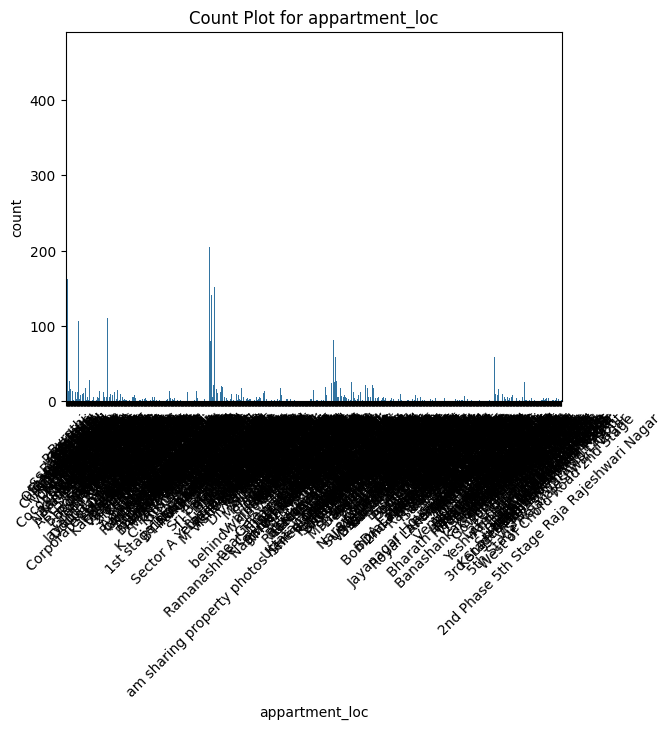

In [162]:
categorical_analysis(df, "appartment_loc")

### apartment_name

,Count,Percentage
apartment_name,,
kvg superior,140,2.14%
prestige waterford,79,1.21%
prestige fsbury park,74,1.13%
kvg aster,67,1.02%
brigade el dorado,55,0.84%
...,...,...
celebration apartment,1,0.02%
amrutha,1,0.02%
priyadarshi paradaise,1,0.02%


**************************************************
Number of unique values in apartment_name: 2476
**************************************************
Unique values in apartment_name: ['sattva songbird' 'brigade sanctuary' 'sobha neopolis' ...
 '5 elements lotus' 'zotra eden' 'lea sunflower']
**************************************************


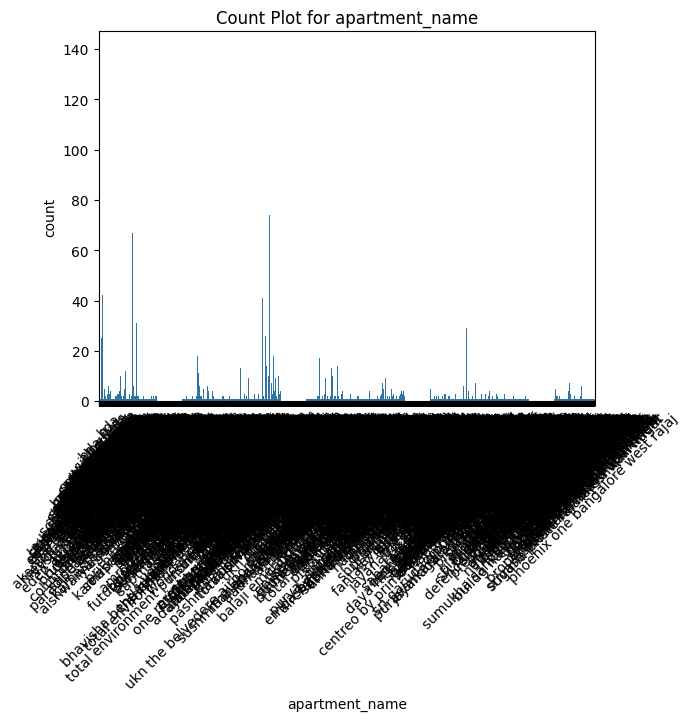

In [163]:
categorical_analysis(df, "apartment_name")

### Zone

,Count,Percentage
zone,,
east,2269,34.58%
north,2011,30.65%
south,1483,22.6%
west,799,12.18%


**************************************************
Number of unique values in zone: 4
**************************************************
Unique values in zone: ['east' 'north' 'south' 'west']
**************************************************


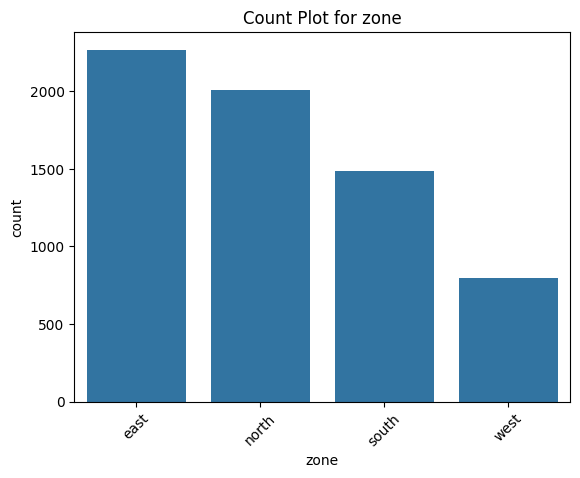

In [164]:

categorical_analysis(df, "zone")

### bhk_type

,Count,Percentage
bhk_type,,
3,2596,39.56%
2,2358,35.93%
4,1049,15.99%
1,559,8.52%


**************************************************
Number of unique values in bhk_type: 4
**************************************************
Unique values in bhk_type: [1, 2, 3, 4]
Categories (4, int64): [1, 2, 3, 4]
**************************************************


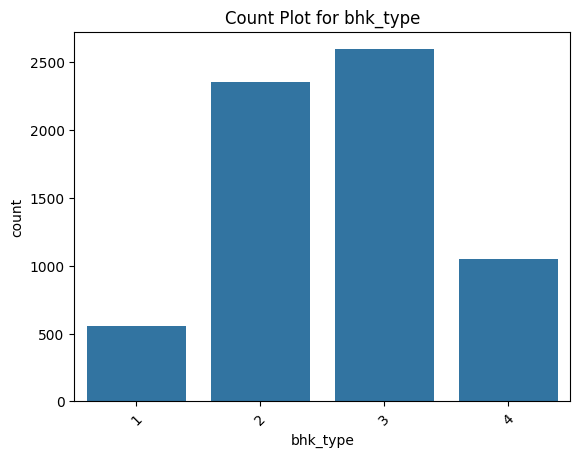

In [165]:
df['bhk_type'] = df['bhk_type'].astype('category')
categorical_analysis(df, "bhk_type")

,Count,Percentage
construction_status,,
New Property,2082,31.73%
Relatively New,2048,31.21%
Under Construction,1180,17.98%
Moderatly Old,825,12.57%
Old,356,5.43%
undefined,71,1.08%


**************************************************
Number of unique values in construction_status: 6
**************************************************
Unique values in construction_status: ['Under Construction' 'New Property' 'Relatively New' 'Moderatly Old'
 'Old' 'undefined']
**************************************************


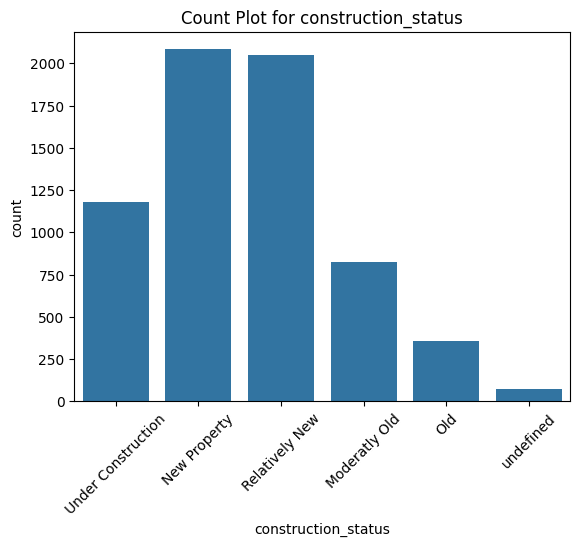

In [166]:
categorical_analysis(df, "construction_status")

# Numerical categorical analysis

In [167]:
def numerical_categorical_analysis(df, cat_col, num_col):
    fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
    # plot the barplot
    sns.barplot(x=cat_col, y=num_col, data=df, ax=ax[0, 0])
    # plot the boxplot
    sns.boxplot(x=cat_col, y=num_col, data=df, ax=ax[0, 1])
    # plot the violin plot
    sns.violinplot(x=cat_col, y=num_col, data=df, ax=ax[1, 0])
    # plot the strip plot
    sns.stripplot(x=cat_col, y=num_col, data=df,dodge=True, ax=ax[1, 1])
    plt.tight_layout()
    plt.show()

def anova_test(df, cat_col, num_col,alpha=0.05):

    data = (
        df.loc[:, [cat_col, num_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for name, group in cat_group]
    f_statistic, p_value = f_oneway(*groups)
    print(f"ANOVA test results for {cat_col} and {num_col}:")
    print(f"F-statistic: {f_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    # Check if the null hypothesis can be rejected
    if p_value <= alpha:
        print(f"Reject the null hypothesis at alpha = {alpha}")
    else:
        print(f"Fail to reject the null hypothesis at alpha = {alpha}")

In [168]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

### construction_status vs price_value

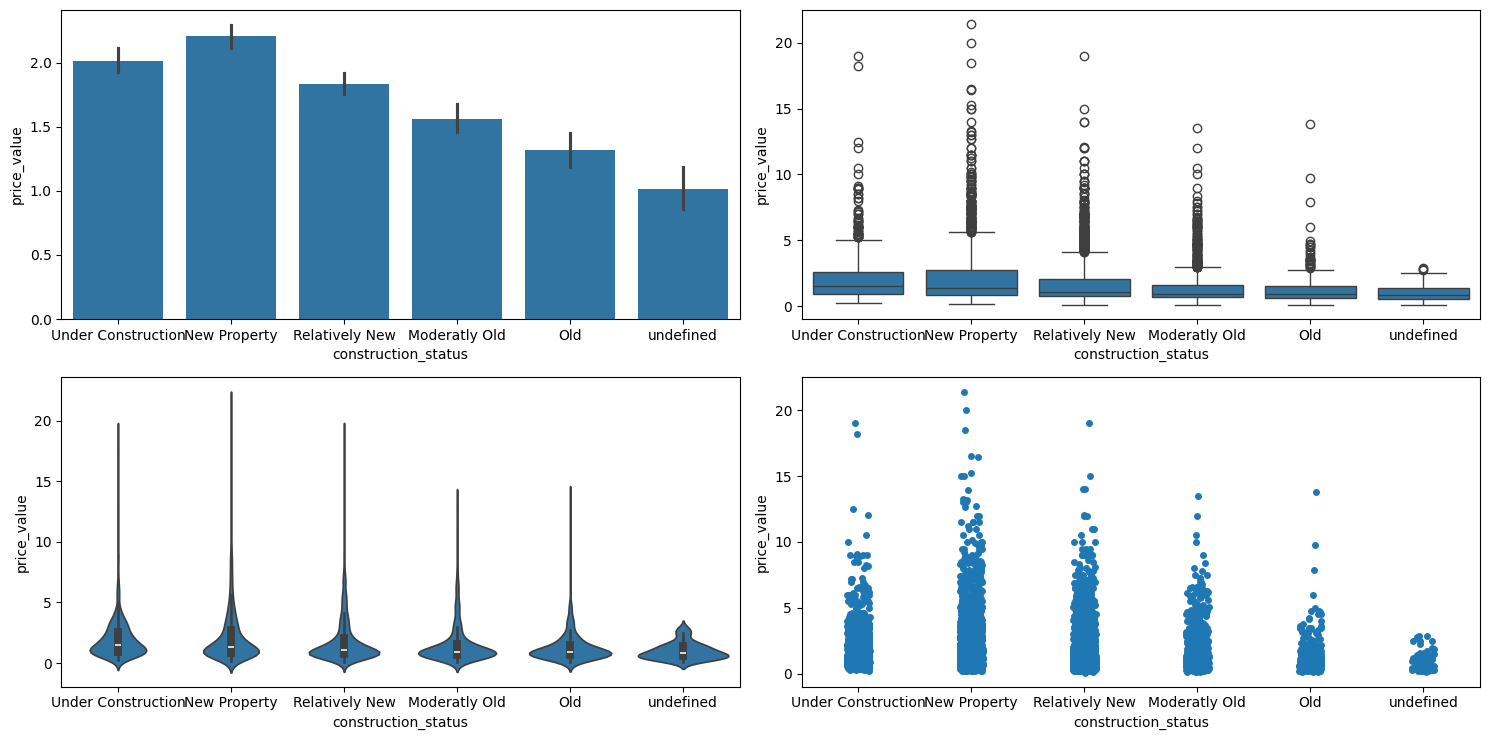

In [169]:
numerical_categorical_analysis(df,"construction_status","price_value")

In [170]:
anova_test(df,"construction_status","price_value")


ANOVA test results for construction_status and price_value:
F-statistic: 26.5243
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


----
**observations** : Thier is significant relationship between the price and the construction status(verfied by ANOVA test).  
New property,Under construction and relatively new construction status have higher price than the rest of the construction status.

----

In [171]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

### bhk_type vs price_value

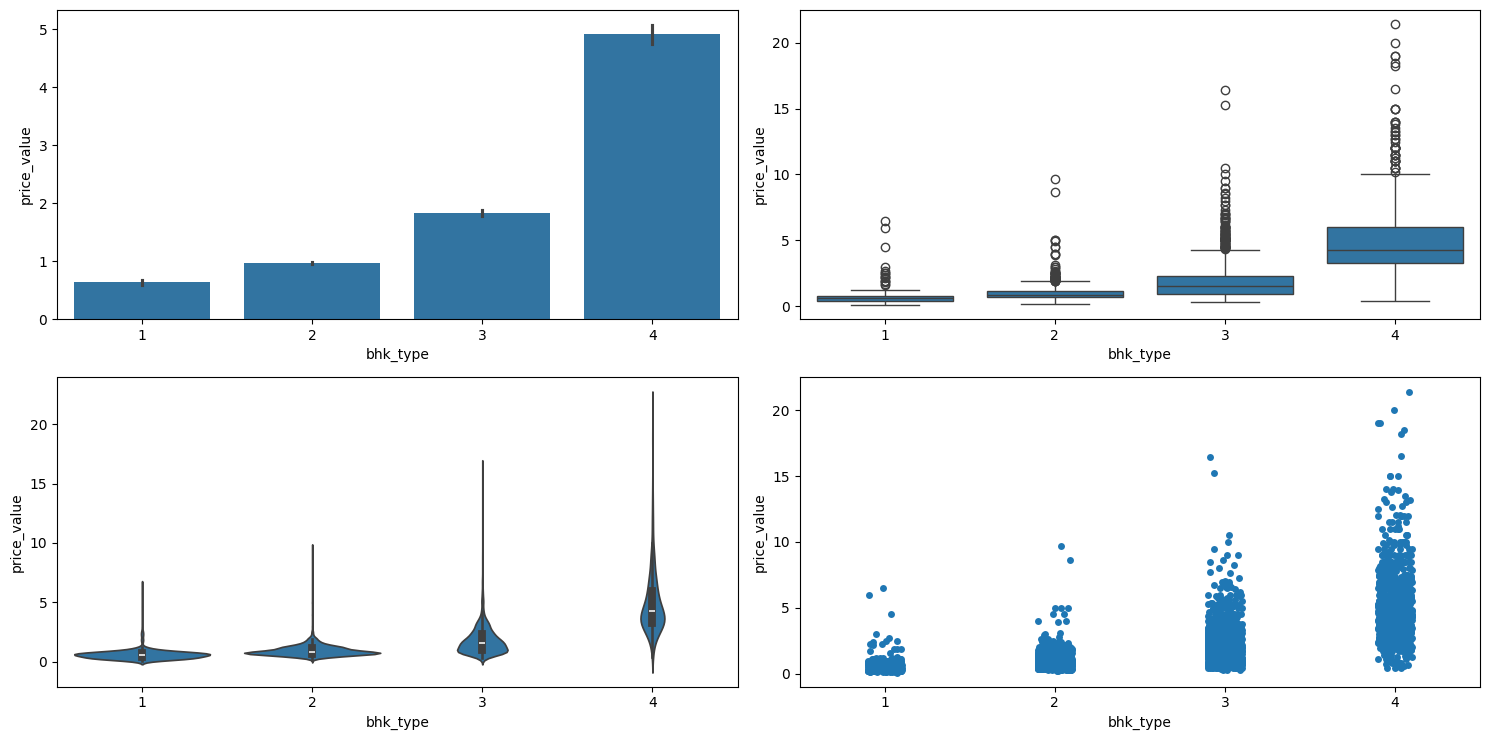

In [172]:
numerical_categorical_analysis(df,"bhk_type","price_value")

-----

Observation: Its evident from the graph that as the bedrooms increase the price of the apartment also increases.

____

### zone vs price_value

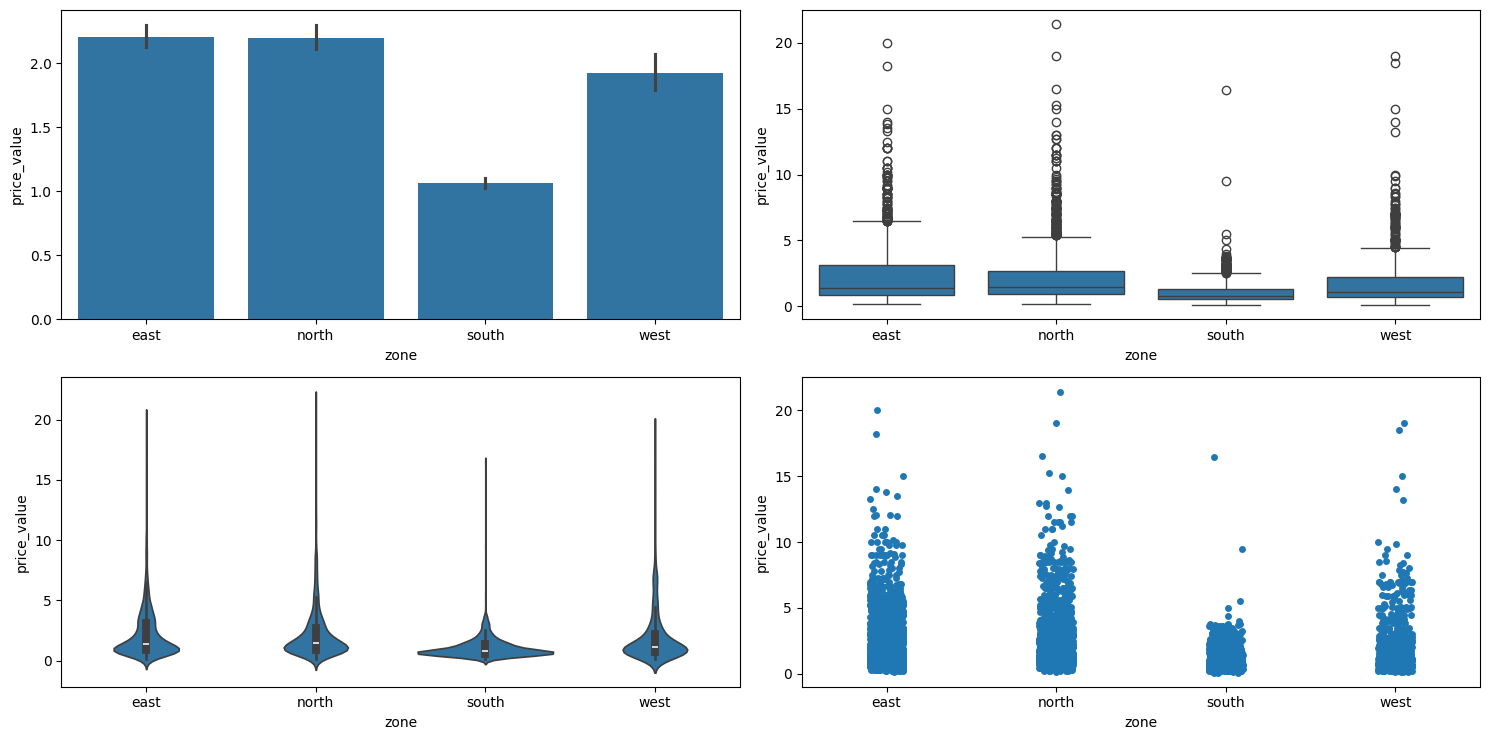

In [173]:
numerical_categorical_analysis(df,"zone","price_value")

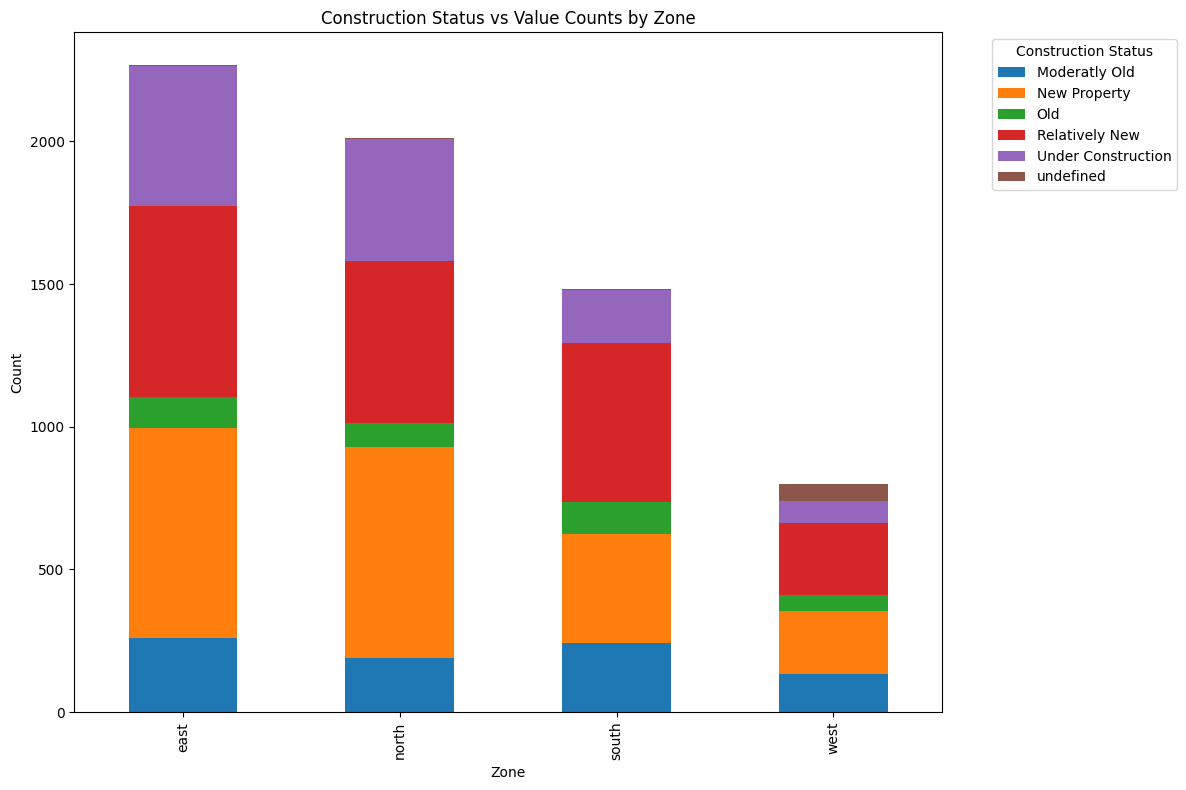

In [174]:
grouped_data = df.groupby("zone")['construction_status'].value_counts().unstack()

# Plot the data
grouped_data.plot(kind='bar', stacked=True, figsize=(12, 8))

# Add labels and title
plt.title("Construction Status vs Value Counts by Zone")
plt.xlabel("Zone")
plt.ylabel("Count")
plt.legend(title="Construction Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [175]:
anova_test(df,"zone","price_value")

ANOVA test results for zone and price_value:
F-statistic: 135.6089
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


------
**Observation**: South Bangalore is part of the older, more established areas.  
 Sometimes established areas have more regulated or stable pricing compared to rapidly developing areas that see price inflation. 
 
 The high F-statistic (212.5602) further indicates that the variation between zones is much larger than the variation within zones, suggesting that:

The differences in price values between zones are not due to random chance
Zone location is a meaningful factor that influences price values
The effect is quite strong, given the large F-statistic

This statistical evidence aligns with what we observed visually in the plots, where the South zone clearly had lower price values compared to East, North, and West zones.

-----


### construction_status vs bulit_area

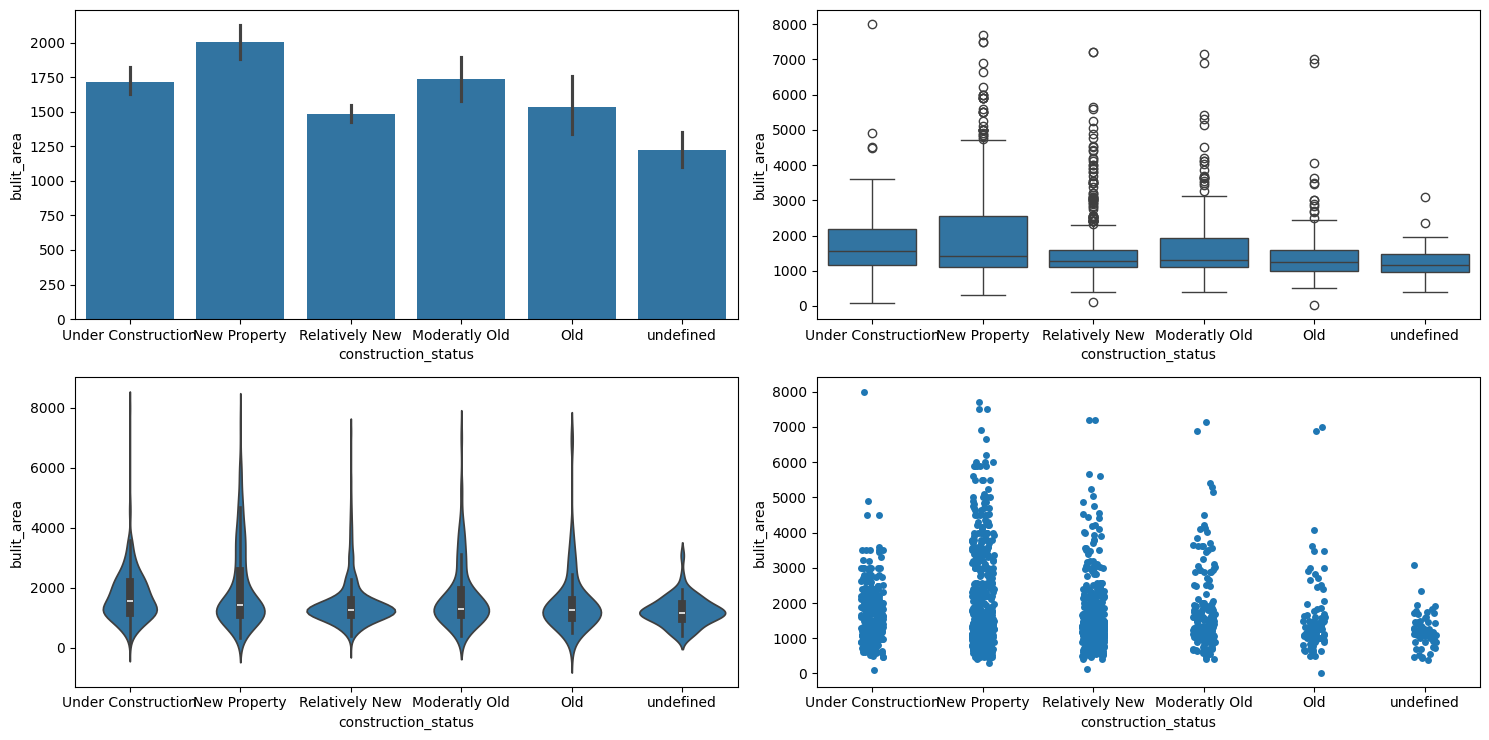

In [176]:
numerical_categorical_analysis(df,"construction_status","bulit_area")

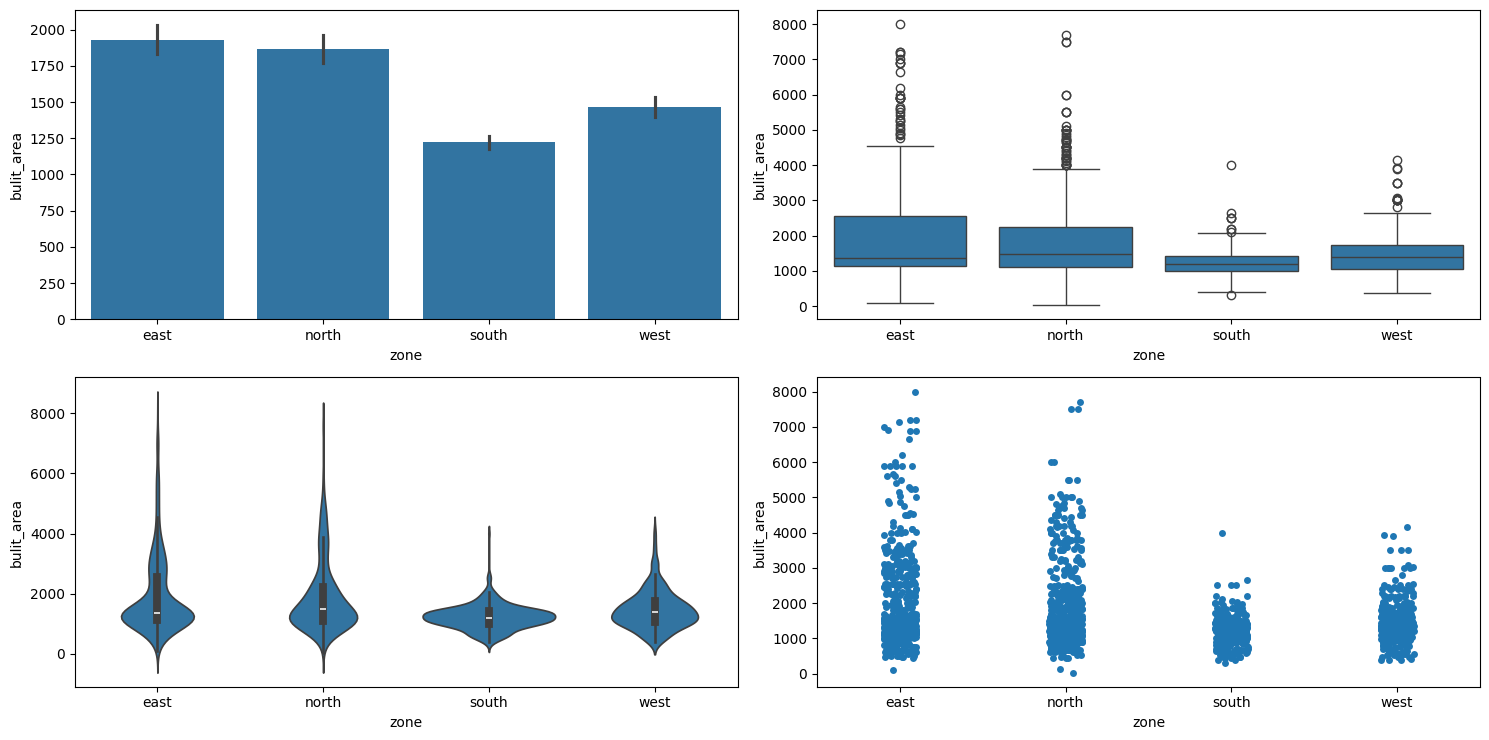

In [177]:
numerical_categorical_analysis(df,"zone","bulit_area")

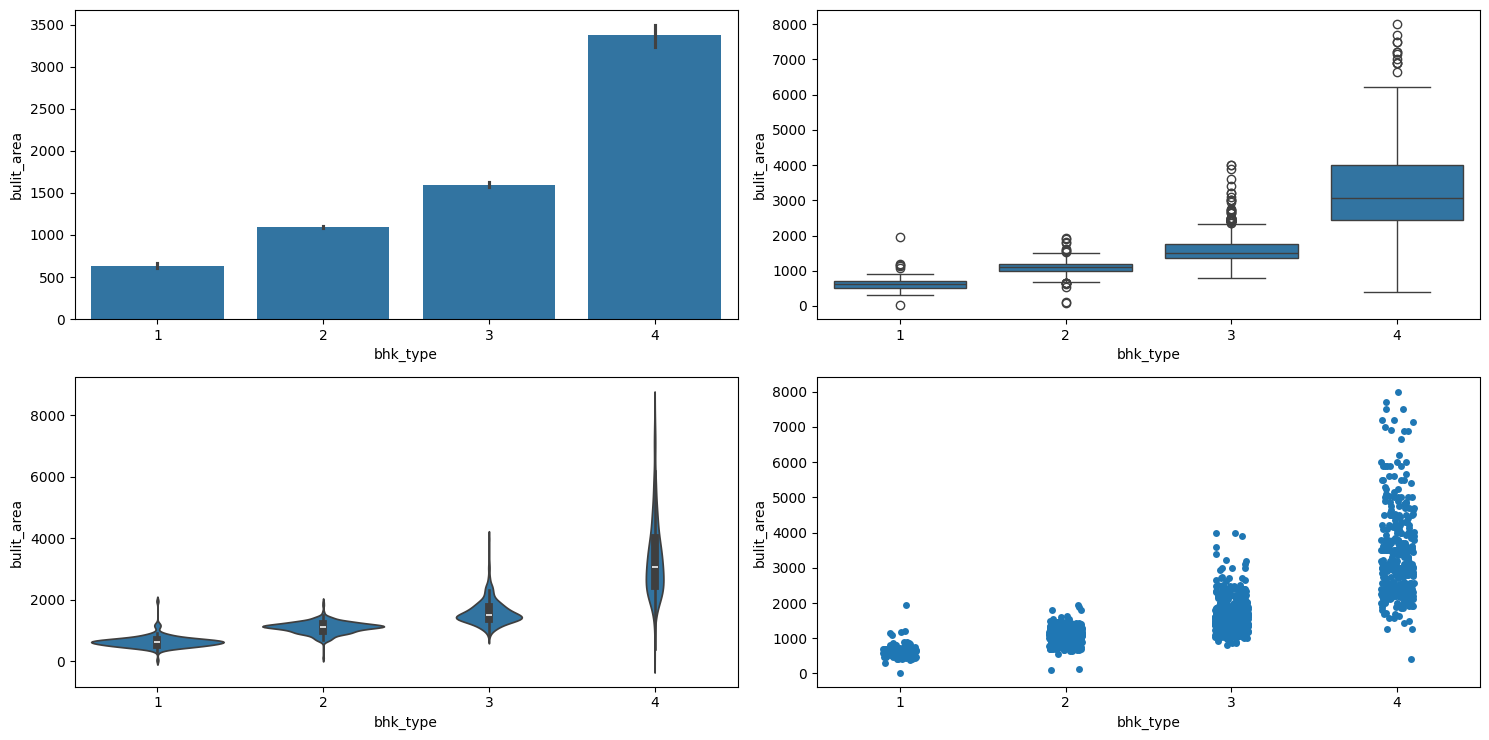

In [178]:
numerical_categorical_analysis(df,"bhk_type","bulit_area")

### apartment_name vs price_value

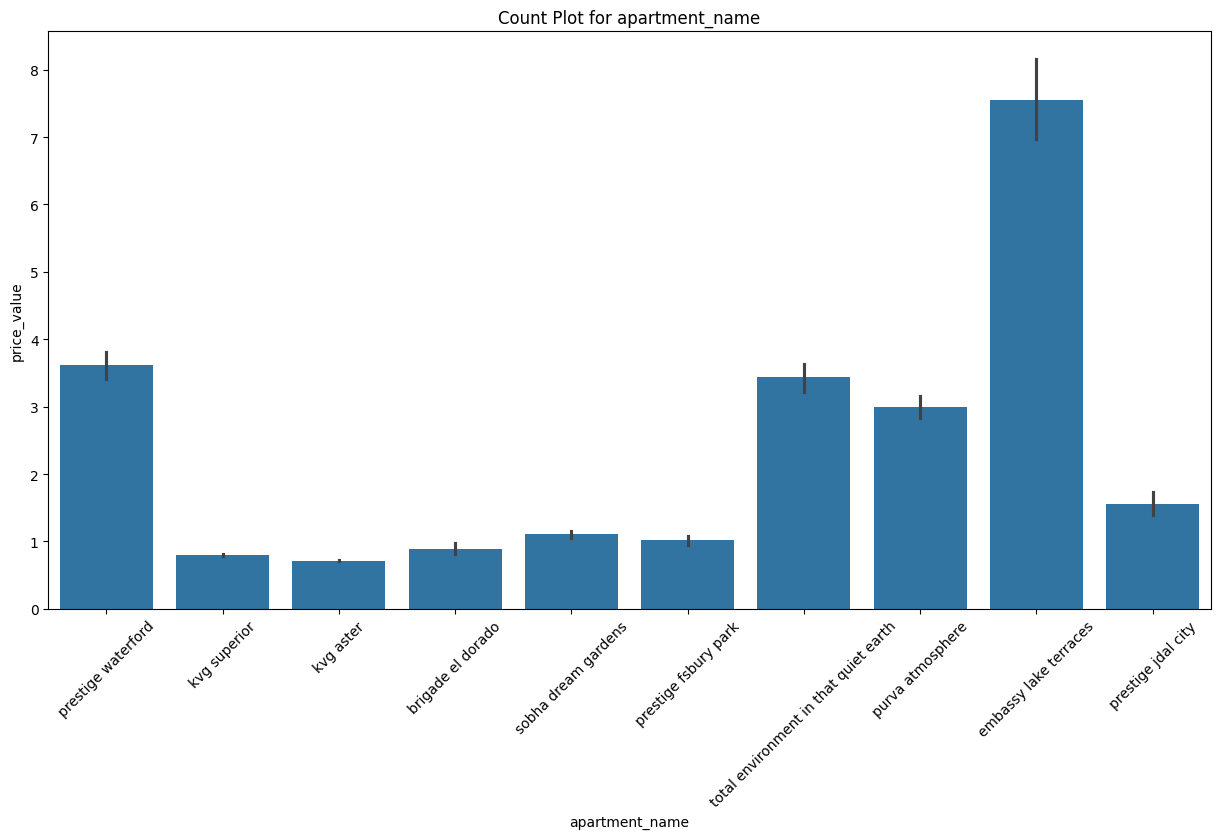

In [179]:
df_freq_appartment = df['apartment_name'].value_counts()[:10].index
sub_df= df[df['apartment_name'].isin(df_freq_appartment)][['apartment_name','price_value']]

fig, ax = plt.subplots(figsize=(15, 7.5))
sns.barplot(x='apartment_name', y='price_value', data=sub_df, ax=ax)
plt.xticks(rotation=45)
plt.title("Count Plot for apartment_name")
plt.show()

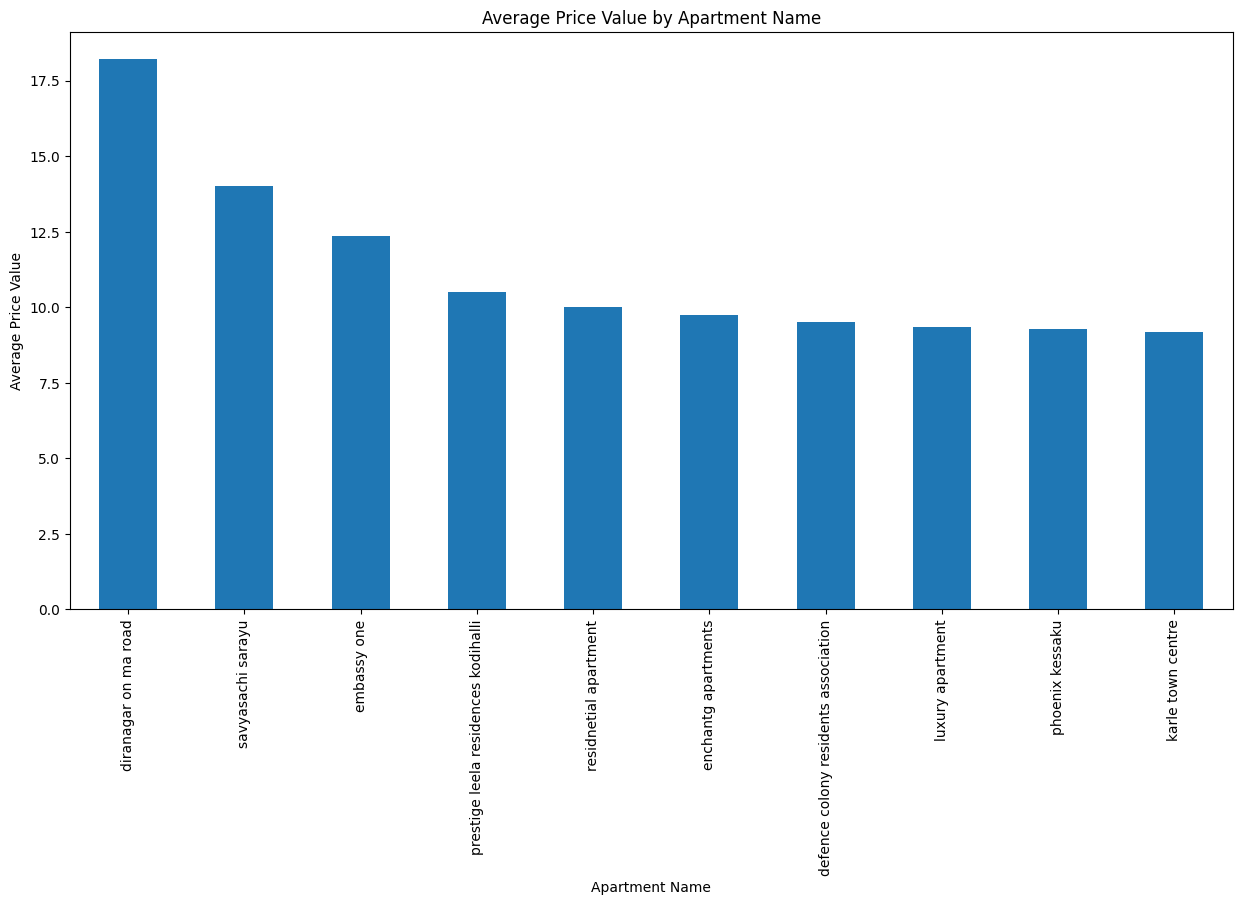

In [180]:
sub_df_avg_costly = df.groupby('apartment_name')['price_value'].mean().sort_values(ascending=False)[:10]
sub_df_avg_costly.plot(kind='bar', figsize=(15, 7.5))
plt.title("Average Price Value by Apartment Name")
plt.xlabel("Apartment Name")
plt.ylabel("Average Price Value")
plt.show()

### apartment_loc vs price_value

In [181]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

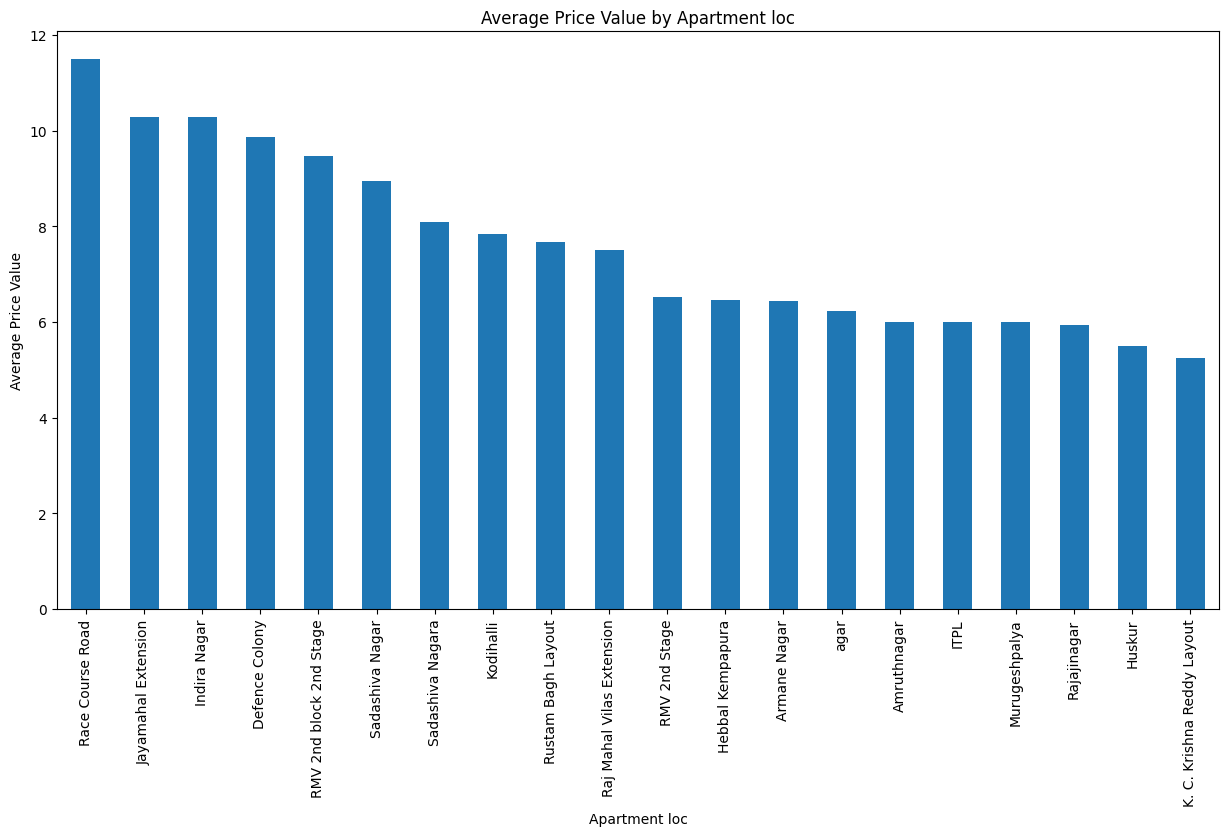

In [182]:
sub_df_avg_costly = df.groupby('appartment_loc')['price_value'].mean().sort_values(ascending=False)[:20]
sub_df_avg_costly.plot(kind='bar', figsize=(15, 7.5))
plt.title("Average Price Value by Apartment loc")
plt.xlabel("Apartment loc")
plt.ylabel("Average Price Value")
plt.show()

# Multi-variable analysis

In [183]:
def multivariate_analysis(df, num_col, cat_col_1, cat_col_2):
    fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
    # plot the barplot
    sns.barplot(x=cat_col_1, y=num_col, hue=cat_col_2, data=df, ax=ax[0, 0])
    # plot the boxplot
    sns.boxplot(x=cat_col_1, y=num_col, hue=cat_col_2, data=df, ax=ax[0, 1])
    # plot the violin plot
    sns.violinplot(x=cat_col_1, y=num_col, hue=cat_col_2, data=df, ax=ax[1, 0])
    # plot the strip plot
    sns.stripplot(x=cat_col_1, y=num_col, hue=cat_col_2,dodge=True, data=df, ax=ax[1, 1])
    plt.tight_layout()
    plt.show()

In [184]:
df.columns

Index(['apartment_name', 'appartment_loc', 'zone', 'bhk_type',
       'construction_status', 'carpet_area', 'bulit_area', 'super_bulit_area',
       'price_value', 'nearbylocation', 'facility', 'luxury_facility_scores',
       'price_value_pt', 'price_value_log'],
      dtype='object')

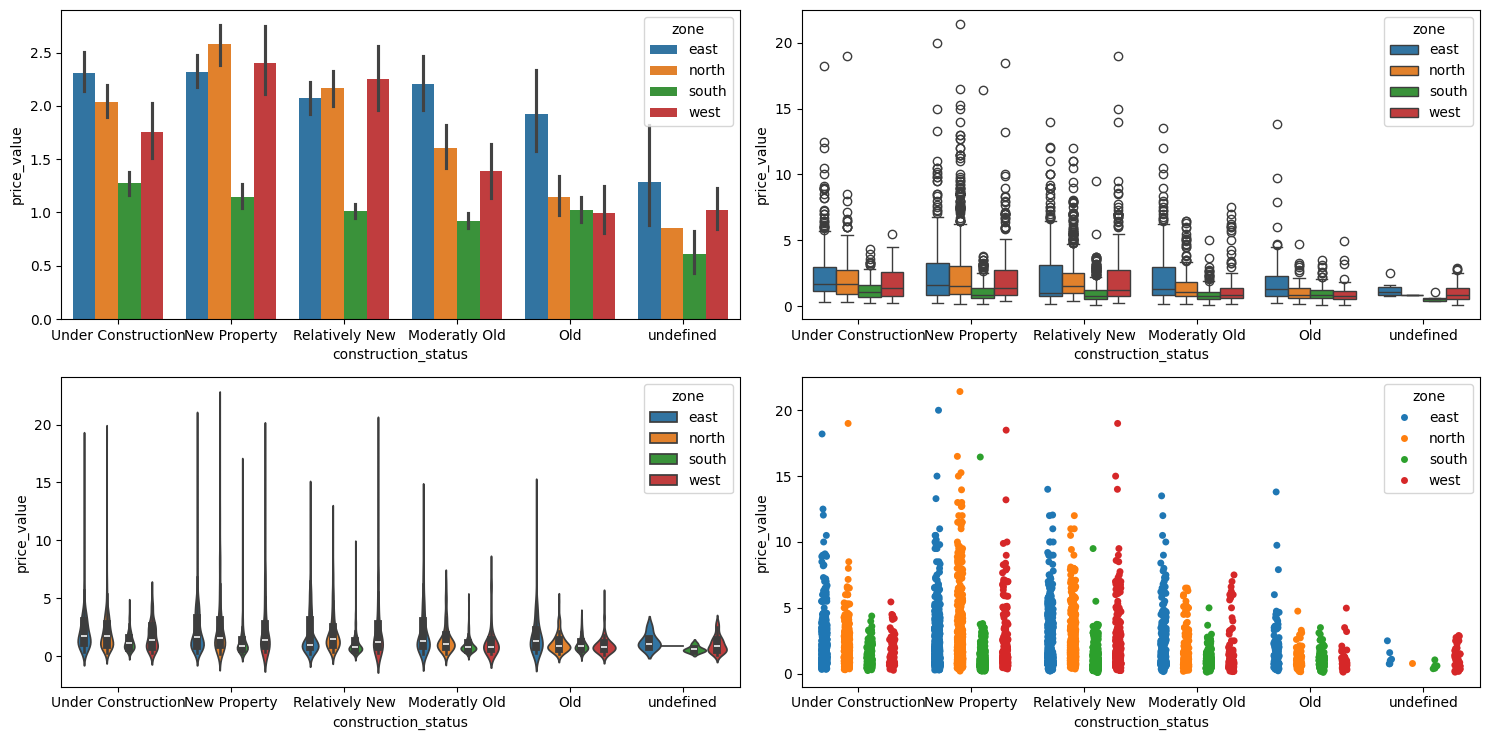

In [185]:
multivariate_analysis(df,"price_value","construction_status","zone")

-----
**Observations:**
South zone consistently has the lowest prices across all construction statuses:

Regardless of whether properties are new, under construction, or old, South zone properties generally have the lowest price values compared to the other zones.


**Price trends across construction statuses:**

New Properties and Under Construction properties tend to have the highest price values across all zones, particularly in East, North, and West.
The North zone shows especially high values for New Properties, with the highest bar in that category.
West zone shows notably high values for undefined and Relatively New properties.


**East zone consistency:**

East zone maintains relatively high price values across most construction statuses, with particular strength in Under Construction, New Property, and Moderately Old categories.

---------

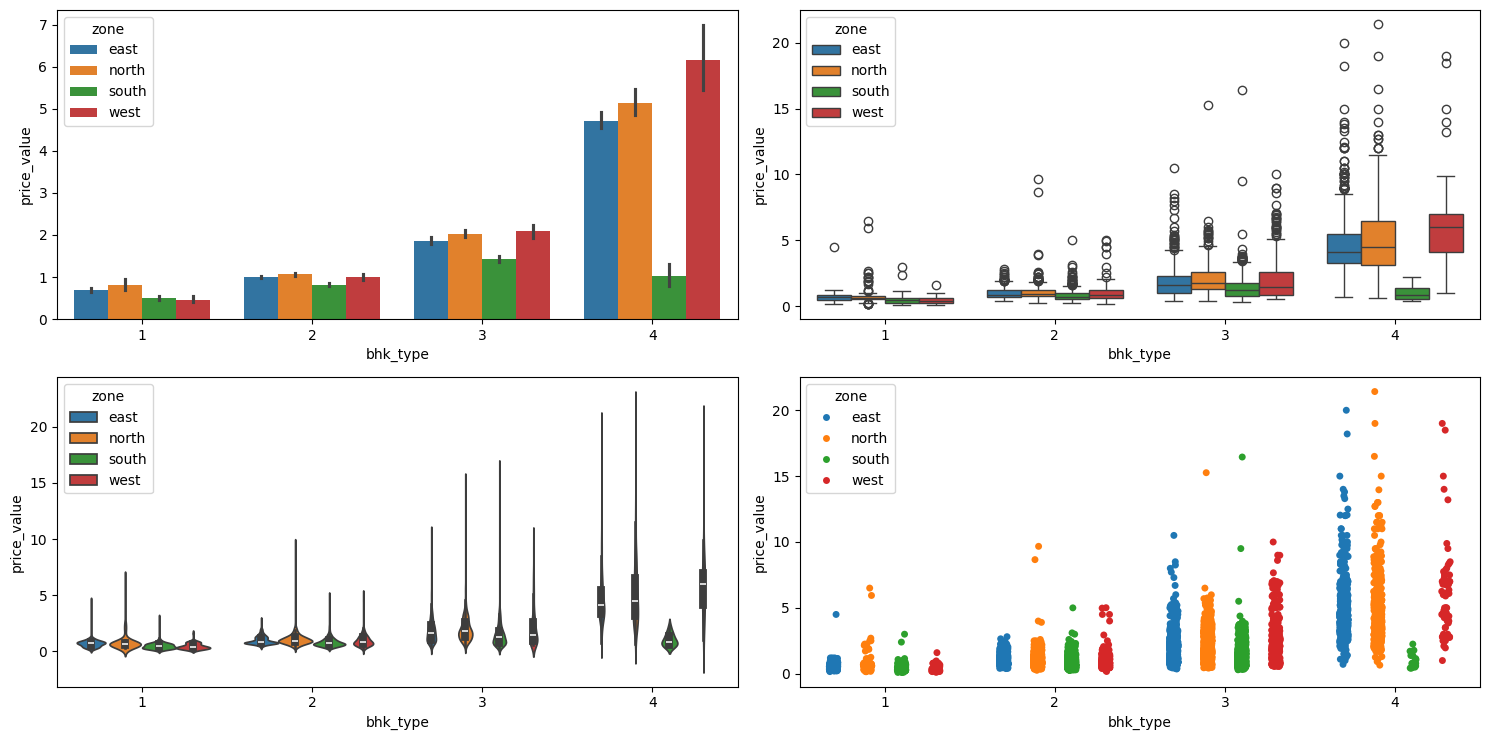

In [186]:
multivariate_analysis(df,"price_value","bhk_type","zone")

---------
**Observations:**
Clear price progression with BHK size:

Across all zones, price values increase steadily as the BHK type increases from 1 to 4
The jump in prices appears most dramatic between 3 BHK and 4 BHK properties


South zone consistently shows the lowest prices:

For every BHK type (1, 2, 3, and 4), South zone properties have notably lower price values compared to the other zones
The difference becomes particularly pronounced for larger properties (3 BHK and 4 BHK)


West zone premium for larger properties:

While West zone starts with relatively low prices for 1 BHK properties, it shows the highest prices for 4 BHK properties
This suggests a premium for luxury or larger properties in the West zone


North and East zones follow similar patterns:

Both maintain relatively higher price values across BHK types
They show particularly strong values for 3 BHK and 4 BHK properties

---------

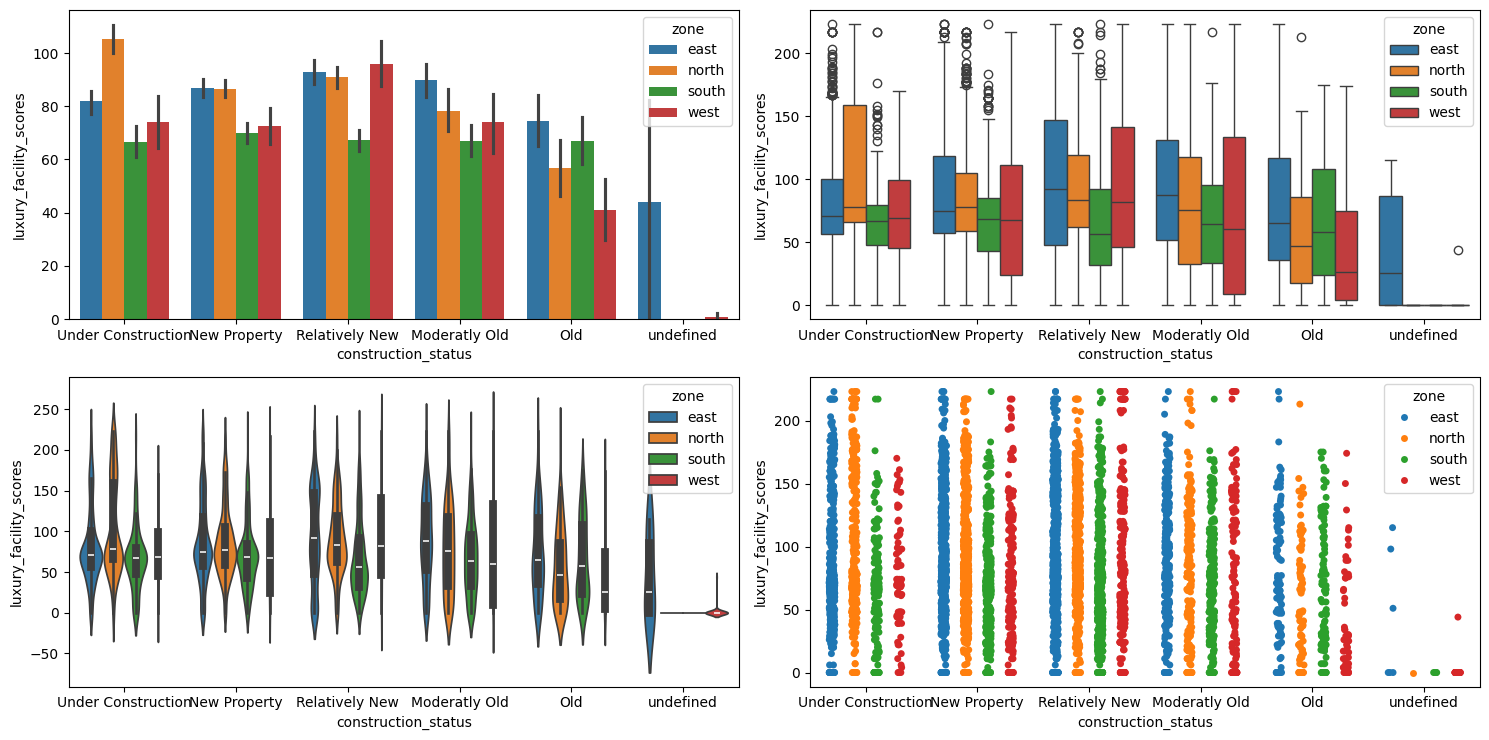

In [187]:
multivariate_analysis(df,"luxury_facility_scores","construction_status","zone")

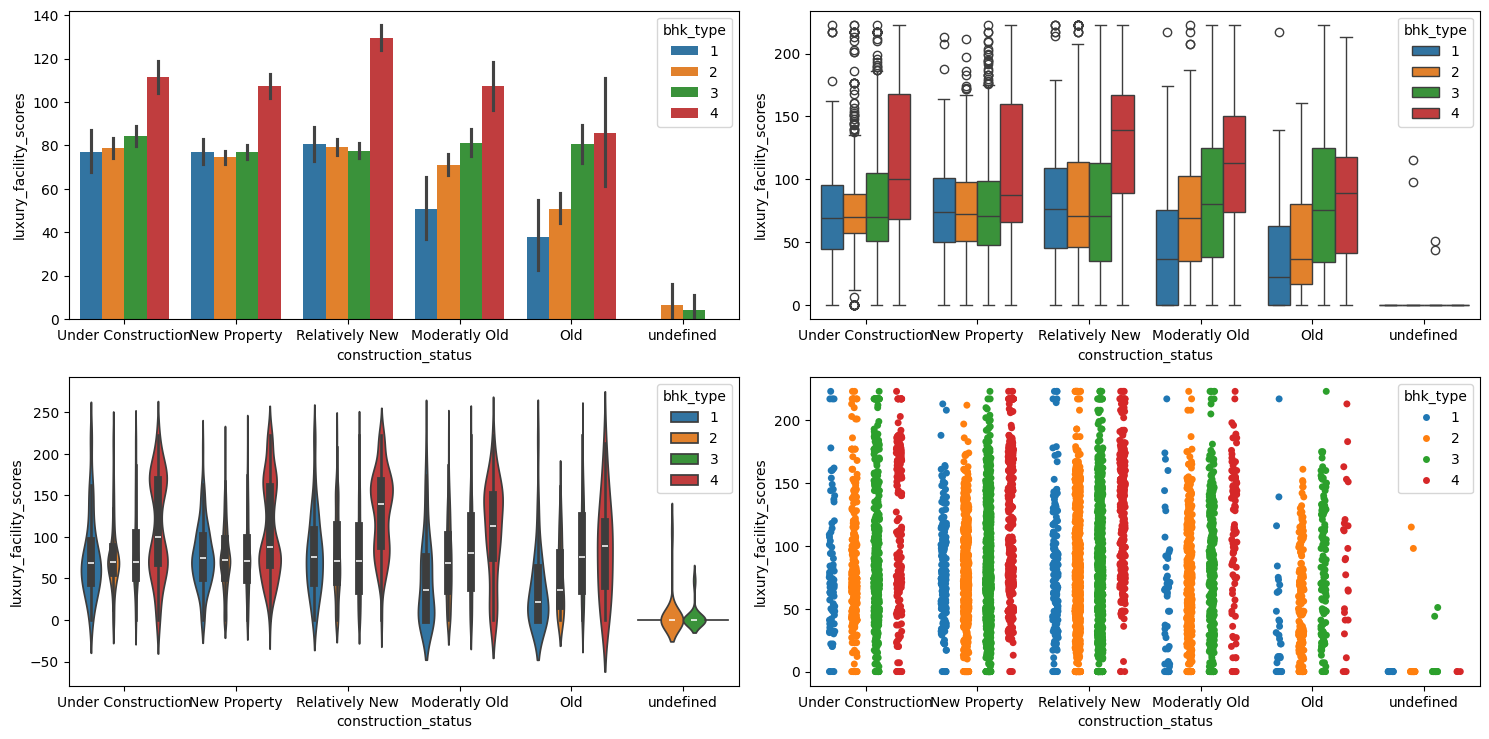

In [188]:
multivariate_analysis(df,"luxury_facility_scores","construction_status","bhk_type")

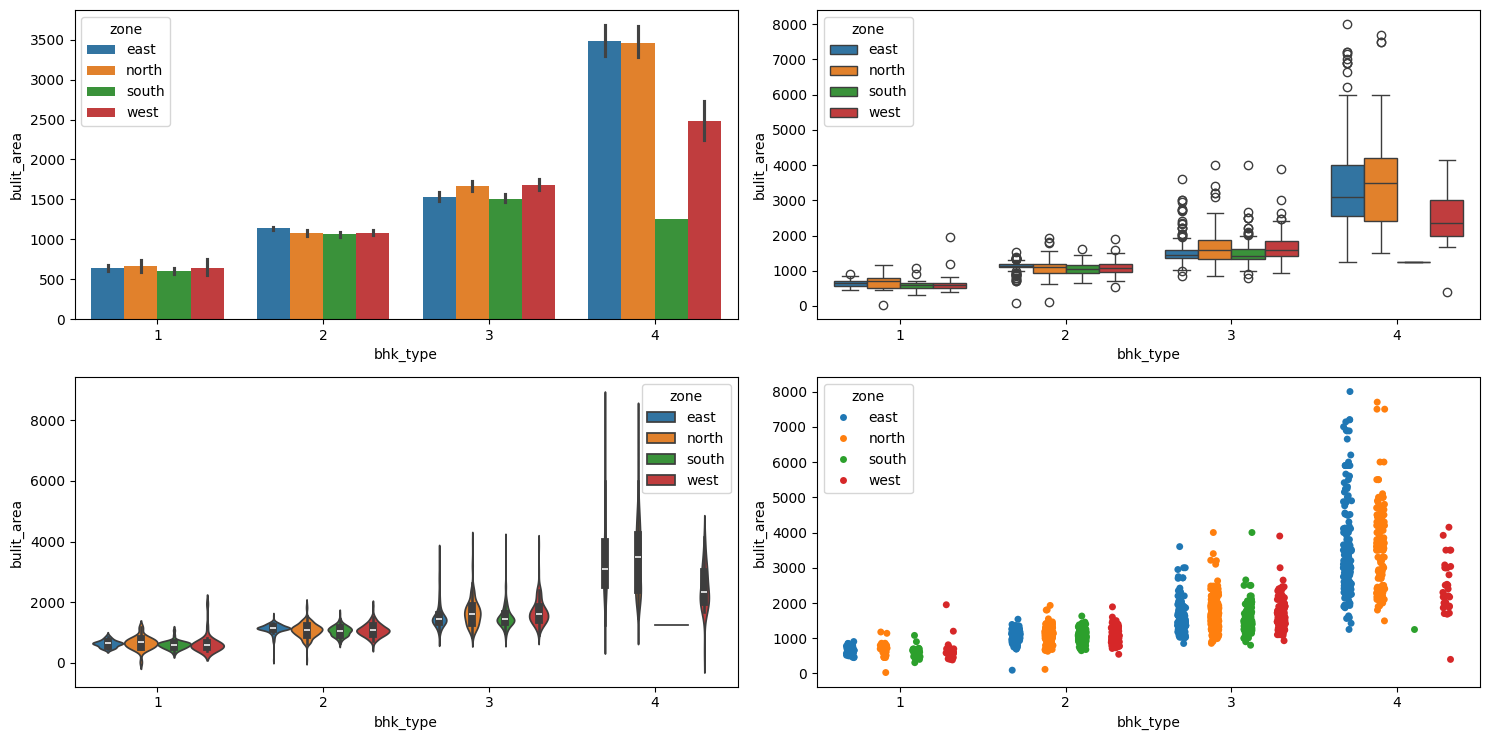

In [189]:
multivariate_analysis(df,"bulit_area","bhk_type","zone")

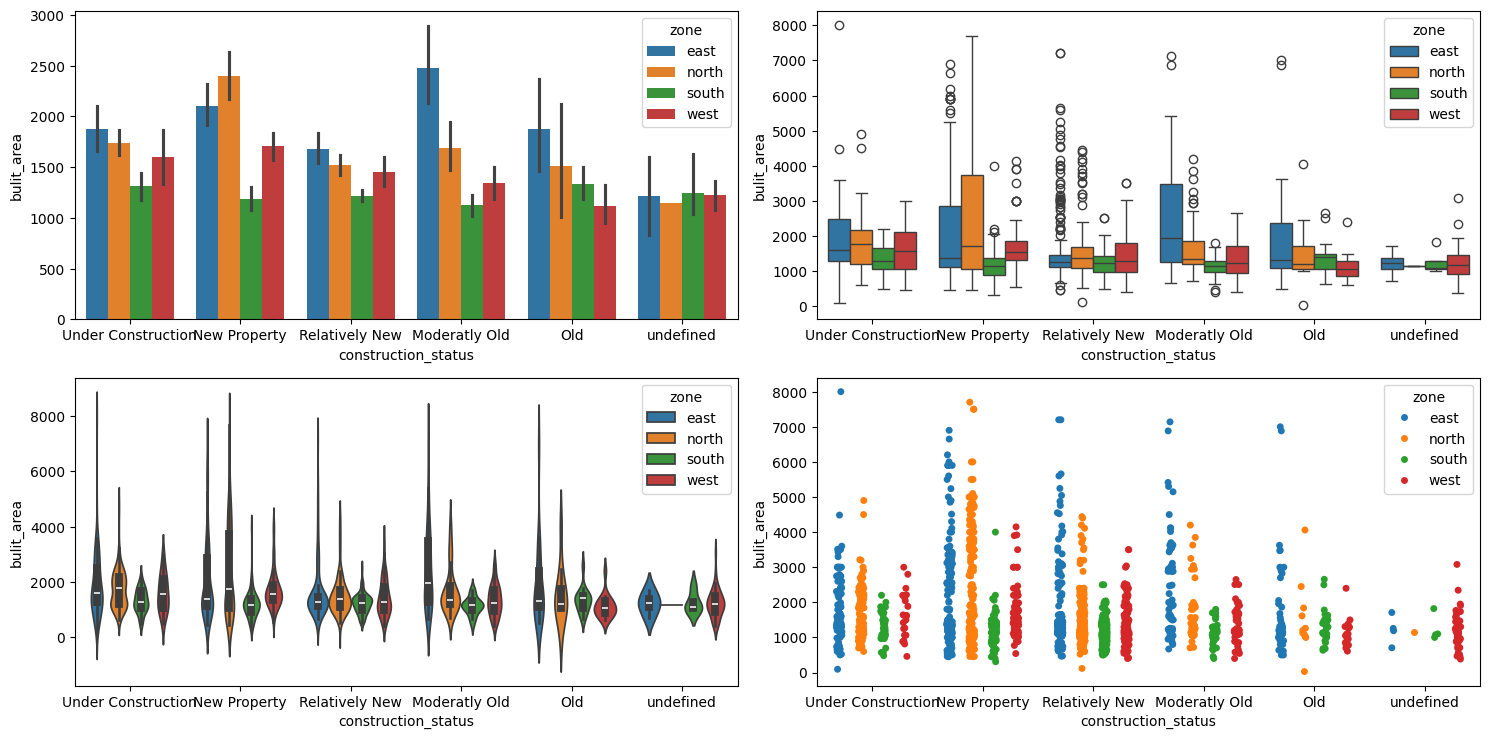

In [190]:
multivariate_analysis(df,"bulit_area","construction_status","zone")

## To check the relationship between the two categorical variables 

In [191]:
def chi2_test(df,col1,col2,alpha=0.05):

    data = (
        df.loc[:, [col1, col2]]
        .dropna()
    )
    # Create a contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # Perform the Chi-Squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Print the results
    print(f"Chi-Squared test results for {col1} and {col2}:")
    print(f"Chi2 statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")

    # Check if the null hypothesis can be rejected
    if p <= alpha:
        print(f"Reject the null hypothesis at alpha = {alpha}")
    else:
        print(f"Fail to reject the null hypothesis at alpha = {alpha}")

In [192]:
## Chi-Squared Test for Independence
chi2_test(df,"construction_status","zone")

Chi-Squared test results for construction_status and zone:
Chi2 statistic: 556.4090
Degrees of freedom: 15
Reject the null hypothesis at alpha = 0.05


In [193]:
chi2_test(df,"construction_status","bhk_type")

Chi-Squared test results for construction_status and bhk_type:
Chi2 statistic: 146.6621
Degrees of freedom: 15
Reject the null hypothesis at alpha = 0.05


In [194]:
chi2_test(df,"zone","bhk_type")

Chi-Squared test results for zone and bhk_type:
Chi2 statistic: 458.1681
Degrees of freedom: 9
Reject the null hypothesis at alpha = 0.05


## To check the relationship between the two numerical variables 

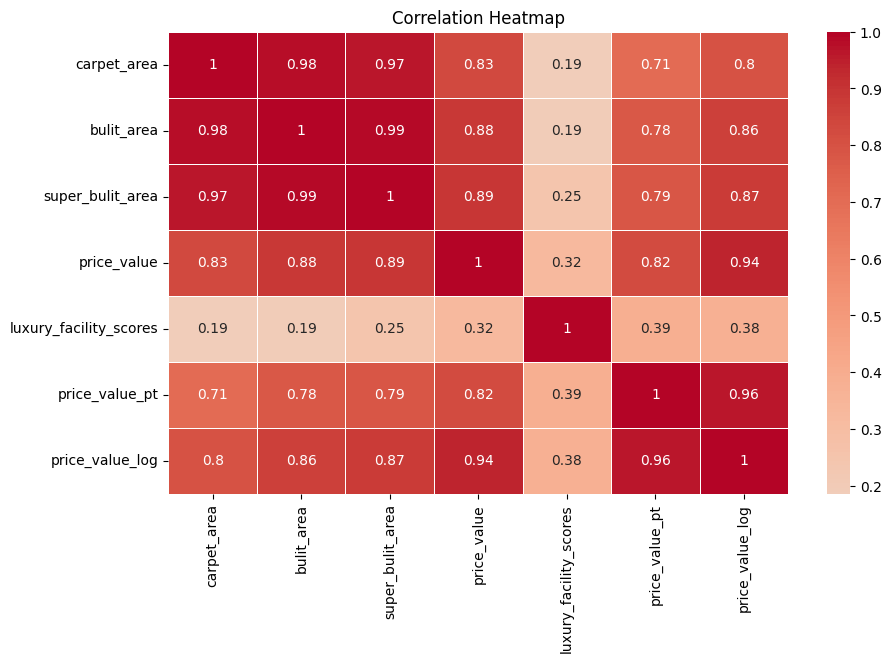

In [195]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()